In [1]:
import os
import random
import time
from datetime import datetime, timedelta
import requests
from bs4 import BeautifulSoup
import re
import gc
from tqdm import tqdm

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
import optuna

import torch
import torch.nn as nn
import torch.utils.data as data

import transformers
from datasets import Dataset
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from transformers import pipeline

In [2]:
import warnings

warnings.simplefilter(action='ignore', category=Warning)

For reproducibility of results:

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
transformers.set_seed(42)

Memory cleaning function:

In [4]:
def clear_memory():
    gc.collect()
    # clearing the GPU cache
    torch.cuda.empty_cache()

Number of logical cores of the system:

In [5]:
import multiprocessing

# count the number of cores in a computer
cores = multiprocessing.cpu_count()
# the same
# os.cpu_count()

cores

4

Since we're working with text, let's change the default Pandas settings:

In [6]:
# overrides the default character limitation in a cell when displaying a dataframe
pd.set_option('display.max_colwidth', None)

Template for all predictions:

In [7]:
submission_template = pd.read_csv('/kaggle/input/competitions/news-topics-competition-2025/base_submission_news.csv')

submission_template.head()

,topic,index
0,0,0
1,0,1
2,0,2
3,0,3
4,0,4


# 1. First look at the data

In [8]:
df_test = pd.read_csv('/kaggle/input/competitions/news-topics-competition-2025/test_news.csv')

df_test.head()

content
0  Фото: «Фонтанка.ру»ПоделитьсяЭкс-министру обороны ДНР Игорю Стрелкову (Гиркину) пришлось уйти в подполье, чтобы встретиться в Петербурге с тридцатью поклонниками. В создании нужной атмосферы были задействованы: один автозак Росгвардии, один кинолог, одна собака, четыре полицейские машины и чертова дюжина силовиков.\n\n\nЗа последние семь лет Стрелков, он же Гиркин, выступал в Петербурге столь часто, что это само по себе перестало быть событием. Предыдущий раз он собирал аншлаг в той же «Листве» в январе 2023-го.\n\n\nКнижная лавка «Листва» на Литейном проспекте принадлежит издательству «Черная сотня», в самом названии которого содержится указание на правый характер сподвижников. Себя считают обществом патриотов. На регулярной основе здесь проходят «встречи с читателями». Военкор Владлен Татарский приходил сюда за несколько часов до взорванной на Университетской набережной бомбы. Бывала в «Листве» и Дарья Дугина. Весной здесь выступал самый известный (между путчем 1991-го и маршем Пригожина 2023-го) мятежник — полковник Квачков.\n\n\nФото: телеграм-канал Листва: ПетербургФото: телеграм-канал Листва: ПетербургПоделитьсяКак правило, рядовые встречи в «Листве» проводятся за счет довольно символических пожертвований в «пользу русской армии». На лекцию со Стрелковым, где темой был заявлен мятеж ЧВК «Вагнер», количество билетов ограничили двадцатью, а цену увеличили 8 раз, до 4 000 рублей. Часть денег, подчеркивают организаторы, предполагалось потратить «на охрану», остальные — на нужды фронта. С учетом ограниченного количества мест речь идет о сумме меньше 100 тысяч рублей. Уже после встречи «Листва» заявила, что на фронт отправят все вырученные средства.\n\n\nТак совпало, что сразу после анонса Стрелкова полиция начала проявлять интерес к людям из «Листвы». Точнее, к одному человеку — организатору мероприятий магазина, члену правого движения «Общество.Будущее» Савве Федосееву. Первый раз его задержали из-за уличного конфликта, который он сам назвал бытовым. Федосеева отпустили тогда без протокола. Во время второго задержания, буквально за два дня до лекции, в информационное поле были вброшены националистические мотивы, полиция сообщила, что предотвратила массовую драку, а а.ру»Фото: Алина Ампелонская / «Фонтанка.ру»Фото: Алина Ампелонская / «Фонтанка.ру»Фото: Алина Ампелонская / «Фонтанка.ру»ПоделитьсяТем временем «разминирование» «Листвы» все больше походило на обыск. Ассортимент книжного магазина полицейские изучали уже без кинолога — тот вместе с собакой уехал в свое Янино. По словам сотрудников лавки, силовики «отрубили» камеры, а внутрь не пускали, в том числе, адвоката. Официальных комментариев и объяснений со стороны полиции не последовало и на следующий день, 10 июля.Фото: телеграм-канал Листва: ПетербургФото: телеграм-канал Листва: ПетербургФото: телеграм-канал Листва: ПетербургФото: телеграм-канал Листва: ПетербургФото: телеграм-канал Листва: ПетербургПоделиться\n\n\nО новой локации участников проинформировали по телефону. Свое помещение предоставило петербургское отделение партии «Другая Россия Э.В. Лимонова». Федосеев рассказал «Фонтанке», что заранее подготовили запасной план. Ни один слушатель, как утверждают в «Листве», не отказался — приехали все. Аудитория в итоге даже увеличилась до 30 человек. На входе охрана досмотрела рюкзаки и сумки. Всех присутствующих попросили воздержаться от публикации фотографий до конца мероприятия и добавили, что адвокат, если вдруг прибудет полиция, присутствует.\n\n\nФото: «Фонтанка.ру»Фото: «Фонтанка.ру»Фото: «Фонтанка.ру»Поделиться\n\n\nНа лекцию Стрелков прибыл ровно к восьми часам. Пошутил, что жена просила уложиться в 15 минут. Лекция обошлась без откровений: экс-министр обороны сразу сказал, что практически обо всем уже писал в своем телеграм-канале, а информация у него не инсайдерская, «основанная на собственном анализе». Минут сорок он говорил непосредственно о мятеже, потом два с лишним часа отвечал на вопросы. Если вы хоть немного следите за тем, что обычно говори

In [9]:
# full text of one news
df_test.loc[1, 'content']

'В начале февраля 2023 года в Пушкинском районе Санкт-Петербурга введён в эксплуатацию новый малоэтажный жилой комплекс. Сведения об объекте капитального строительства внесены в специальный кадастр недвижимости.Фото: ООО «СЗ «ТЕРМИНАЛ-РЕСУРС»ПоделитьсяКадастровый учёт осуществляет Федеральная служба государственной регистрации, кадастра и картографии — Росреестр. Поставить дом на кадастровый учёт означает внести в базу его основные характеристики: наименование, адрес, назначение, этажность, ситуационный план, а также кадастровый номер. Это необходимо для оформления права собственности на объект недвижимости, а также последующего распоряжения собстве о договору купли-продажи. На готовые квартиры от застройщика распространяются все программы льготной ипотеки, как и на строящиеся объекты.Квартиры в Пушкинском районе: г. Санкт-Петербург, ул. Кокколевская, д.1, БЦ «Перспектива» (отдел продаж рядом с «Образцовыми кварталами»), +7 (812) 719–19–19, www.devcent.ruСправка о компании ООО «СЗ «Тер

**We don't have train data, so we need to obtain it from open sources. Therefore, we can't perform EDA yet.**

# 2. Data scratching and parsing

We'll analyze several Russian-language news sites. It's important that the news topics on these sites align with our own.

In [10]:
topics = {'Общество/Россия': 0,
          'Экономика': 1,
          'Силовые структуры': 2,
          'Бывший СССР': 3,
          'Спорт': 4,
          'Забота о себе': 5,
          'Строительство': 6,
          'Туризм/Путешествия': 7,
          'Наука и техника' : 8
         }

**2.1 Parsing from lenta.ru**

We'll start with lenta.ru.

For example, let's try to parse one page using BeautifulSoup:

In [11]:
url = 'https://lenta.ru/news/2026/05/12/rossiyane-massovo-pozhalovalis-na-kleschey/'
response = requests.get(url)

response.status_code

200

In [12]:
tree = BeautifulSoup(response.content, 'html.parser')

header = tree.find('span', {'class': 'topic-body__title'}).text
subheader = tree.find('div', {'class': 'topic-body__title-yandex'}).text
topic = tree.find('a', {'class': 'topic-header__item topic-header__rubric'}).text
date = tree.find('a', {'class': 'topic-header__item topic-header__time'}).text
# find_all returns ResultSet
text_tag = tree.find_all('p', {'class': 'topic-body__content-text'})

# getting text from ResultSet
text = ' '.join(i.text for i in text_tag)

print(header)
print(subheader)
print(topic)
print(date)
print(text)

Россияне массово пожаловались на клещей
Роспотребнадзор: Более 43 тысяч россиян пожаловались на укусы клещей
Экономика
07:38, 12 мая 2026
С начала сезона более 43 тысяч россиян обратились в учреждения с укусами клещей. О массовых жалобах на вредителей сообщает Роспотребнадзор, пишет РИА Новости. «Всего с начала сезона зарегистрировано более 43 тысяч обращений в медицинские организации по поводу укусов клещей», — рассказали в ведомстве. При этом от клещевого энцефалита привиты порядка 2,2 миллиона россиян, подчеркнули в Роспотребнадзоре. Чаще всего вредители кусали жителей Челябинской, Тверской, Омской, Иркутской, Московской, Ленинградской, Костромской, Самарской областей, Алтайского и Краснодарского краев, Республики Алтай и Санкт-Петербурга. Ранее стало известно, что 52 процента россиян никак не защищаются от клещей. Многие из тех, кто пренебрегает защитой, заявили, что не ходят в лес и не верят, что могут пострадать от клещей дома. Некоторые отметили, что бывают в лесу, но все равно 

Now we need to write class with functions that will receive news for a certain period and convert them into a dataframe.

In [13]:
class LentaParser:
    """
    Collects news from the website lenta.ru.
    """
    
    def get_url(self, params):
        """
        Returns a URL for requesting a JSON table with news.
        The site's search engine is used, returning JSON tables
        with information about articles upon request.
    
        from - offset (we skip this amount of news) - from 0 to size;
        size - number of news (conditionally, up to 1000);
        sort - sort by date descending (2), by date ascending (3),
            by relevance (1);
        title_only - the exact phrase in the title;
        domain - ???;
        modified%2Cformat=yyyy-MM-dd& - date format;
        type - materials. News (1), articles (2) ???;
        bloc - topic. Russia (1), world (2), former USSR (3), economy (4),
            science and technology (5), culture (6), internet and media (7)
            and so on;
        modified%2Cfrom - start date;
        modified%2Cto - end date (included);
        query - search query.
    
        The order of key transfer doesn't matter.
        """
        
        url = 'https://lenta.ru/search/v2/process?' \
        + f'from={params['from_']}&' \
        + f'size={params['size']}&' \
        + f'sort={params['sort']}&' \
        + 'modified%2Cformat=yyyy-MM-dd&' \
        + f'type={params['type_']}&' \
        + f'modified%2Cfrom={params['date_start']}&' \
        + f'modified%2Cto={params['date_end']}&'
#       + f'title_only={params['title_only']}&' \
#       + f'domain={params['domain']}&' \
#       + f'bloc={params['bloc']}&' \
#       + 'query='
        
        return url
    
    def make_df(self, url):
        """
        Returns a dataframe with news at the specified URL.
        """
        
        response = requests.get(url)
        if response.status_code == 200:
            try:
                # deserialize JSON object
                df = pd.DataFrame(response.json()['matches'])
            except Exception as e:
                print(e)
            else:
                return df
    
    def parse_news(self, params, save_interval=100):
        """
        Function for downloading news in a specified date range.
        Saves dataframe every save_interval days.
        """
        
        params_copy = params.copy()
        date_start = datetime.strptime(params_copy['date_start'], '%Y-%m-%d')
        date_end = datetime.strptime(params_copy['date_end'], '%Y-%m-%d')
    
        # dataframe for results
        df_result = pd.DataFrame()
    
        if date_end < date_start:
            raise ValueError('date_end must be greater than date_start')
        else:
            # counter for saving results
            counter = 0
    
            date_current = date_start
            
            while date_current <= date_end:
                # we make requests to the server at intervals
                delay = random.randint(1, 3)
                time.sleep(delay)
                
                # we don't know in advance how many news items are published on the site each
                # day, and we will download no more than 500 news items at a time. Therefore, with
                # each request to the site, we will only download news for one day
                params_copy['date_start'] = date_current.strftime('%Y-%m-%d')
                params_copy['date_end'] = params_copy['date_start']
                
                url_current = self.get_url(params_copy)
                # we should check if the make_df function returns a valid dataframe
                df_current = self.make_df(url_current)
                if df_current is not None:
                    df_result = pd.concat([df_result, df_current], axis=0,
                                          join='outer', ignore_index=True)
    
                date_current += timedelta(days=1)
    
                counter += 1
                # save intermediate results
                if counter % save_interval == 0:
                    df_result.to_csv('df_lenta.csv', index=False)
    
                # simple logging every 50 iterations
                if counter % 50 == 0:
                    print(f'Current date: {params_copy['date_start']} / {params['date_end']}')
    
        return df_result

In [14]:
# setting parameters
from_ = '0'
size = '500'
sort = '3'
type_ = '1'
date_start = '2024-01-01'
date_end = '2026-05-14'

lenta_params = {'from_': from_,
                'size': size,
                'sort': sort,
                'type_': type_,
                'date_start': date_start,
                'date_end': date_end
               }

lenta_parser = LentaParser()
lenta_url = lenta_parser.get_url(lenta_params)

lenta_url

'https://lenta.ru/search/v2/process?from=0&size=500&sort=3&modified%2Cformat=yyyy-MM-dd&type=1&modified%2Cfrom=2024-01-01&modified%2Cto=2026-05-14&'

In [15]:
df = lenta_parser.make_df(lenta_url)

df.head()

,docid,url,title,modified,lastmodtime,type,domain,status,part,bloc,tags,image_url,pubdate,text,rightcol,snippet
0,1551031,https://lenta.ru/news/2024/01/01/chetvero-pogibshih-sredi-nih-voenkor-13-chelovek-raneny-vsu-obstrelyali-tsentr-donetska-v-novogodnyuyu-noch/,"Четверо погибших, среди них военкор, 13 человек ранены. ВСУ обстреляли центр Донецка в новогоднюю ночь",1704067200,1704105148,1,1,0,1,3,[55],https://icdn.lenta.ru/images/2024/01/01/02/20240101025852327/detail_a51b52880494fd2ce078ccabb708bc04.jpg,1704067200,"Фото: Keystone Press Agency / Globallookpress.com Марина Совина Вооруженные силы Украины (ВСУ) сразу после наступления Нового года обстреляли центр Донецка. Об этом сообщил глава Донецкой народной республики (ДНР) Денис Пушилин. По состоянию на 02:00, по предварительной информации, 4 человека погибли, 13 получили ранения, отметил Пушилин. До этого он сообщал о трех погибших и семи раненых, всем пострадавшим оказывается медицинская помощь. По данным Совместного центра по контролю и координации режима прекращения огня (СЦЦК) ДНР, было выпущено 15 ракет из реактивных систем залпового огня (РСЗО), из каких именно, не уточняется. Во время удара по центру Донецка погиб военный корреспондент, еще один получил ранения, сообщили в оперативных службах региона. ВСУ обстреляли пятизвездочную гостиницу «Донбасс Палас». Военкор Александр Сладков подтвердил информацию о коллегах. Он подчеркнул, что украинские военные преднамеренно ударили по мирным кварталам Донецка, в том числе по гостинице «Донбасс Палас», где нет ни военных штабов, ни расположений каких-либо подразделений, ни проживающих военачальников. Журналист также указал на слова своего коллеги Андрея Руденко о том, что мудрым оказалось решение не устанавливать новогоднюю елку на площади Ленина, поскольку людей на улице оказалось бы больше. Местный житель Константин рассказал, что при обстреле Донецка люди сначала подумали, что запускался фейерверк. Мужчина вышел на балкон в новогоднюю ночь и услышал звук взрыва. Российские военкоры в Telegram-каналах уточнили подробности обстрела. Как сообщают «Военкоры Русской Весны», массированная атака на Донецк и Токмак началась сразу после полуночи. По Токмаку в Запорожской области наносились удары из реактивных систем залпового огня (РСЗО) HIMARS. Куйбышевский район Донецка обстрелян из гаубиц натовского калибра 155 миллиметров, по Петровскому району города вели огонь кассетными снарядами. В 00:10 по центру столицы ДНР были выпущены 15 ракет из РСЗО. Информацию подтвердил военкор Юрий Котенок. Военный корреспондент Евгений Лисицын уточнил, что часть ракет, выпущенных по Донецку в новогоднюю ночь, перехвачена силами российской противовоздушной обороны (ПВО). Александр Сладков заявил, что по городу было выпущено два пакета РСЗО, возможно, из систем «Град» или «Ольха». Он сообщил, что огневой налет продолжался 25 минут. Журналист подчеркнул, что в городе нет и не было военных. 30 декабря ВСУ обстреляли центр Белгорода ракетами «Ольха» и реактивными системами залпового огня (РСЗО) Vampire чешского производства. Глава Минздрава России Михаил Мурашко сообщил, что от атаки пострадали 109 человек, 22 из них находятся в тяжелом состоянии.","Четверо погибших, среди них военкор, 13 человек ранены. ВСУ обстреляли центр Донецка в новогоднюю ночь","Фото: Keystone Press Agency / ... Нового года обстреляли центр Донецка. Об этом сообщил глава Донецкой народной республики (ДНР) Денис Пушилин. По состоянию на 02:00, по ..., 13 получили ранения, отметил Пушилин."
1,1551032,https://lenta.ru/news/2024/01/01/dietolog-nazvala-samyy-poleznyy-sous/,Диетолог назвала самый полезный соус,1704067620,1704067722,1,1,0,0,87,[354],https://icdn.lenta.ru/images/2024/01/01/03/20240101030857015/detail_c8065744941204bbc1020cca3bf91c48.jpg,1704067620,"Фото: Sara Cervera / Unsplash Марина Совина Кандидат медицинских наук, врач-диетолог Маргарита Арзуманян в беседе с радио Sputnik назвала самый полезный соус. По ее словам, самый полезный соус — тот, который готовят дома.

Now we get a dataframe with the results for all days:

In [16]:
# %%time

# try:
#     df_lenta = lenta_parser.parse_news(lenta_params, save_interval=100)
# except ValueError as e:
#     print(e)

In [17]:
# df_lenta

We need only 'url' (for further topic analysis), 'text' and 'bloc' (our target) columns. And we can save the dataframe to avoid re-parsing it next time.

In [18]:
# df_lenta = df_lenta[['url', 'text', 'bloc']]

# df_lenta.to_csv('df_lenta.csv', index=False, encoding='utf-8')

**2.2 Parsing from rbc.ru**

The rbc.ru provides no more than 20 articles at a time upon request.

It's important to note that rbc.ru doesn't return the full text of the news item, only a summary. To get the full text, you need to go to the url and scrape it manually.

First of all, we need news on the topic of 'construction', because there was none on lenta.ru.

In [19]:
class RbcParser:
    """
    Collects news from the website rbc.ru.
    """
    
    def get_url(self, params):
        """
        Returns a URL for requesting a JSON table with news.
        The site's search engine is used, returning JSON tables
        with information about articles upon request.

        project - rbc projects, possible values:
            [rbcnews, rbctv, rbcstyle, sport, realty, crypto, autonews,
             quote, bc3, trends];
        category - categories, possible values:
            [TopRbcRu_economics, TopRbcRu_auto, TopRbcRu_business,
             TopRbcRu_money, TopRbcRu_realty, TopRbcRu_society,
             TopRbcRu_politics, TopRbcRu_own_business, TopRbcRu_specials,
             TopRbcRu_technology_and_media, TopRbcRu_finances];
        dateFrom - start date;
        dateTo - end date (included);
        page - search results offset (in increments of 20);
        query - search query (keyword), e.g., RBC;
        material - materials, possible values:
             [video, quiz, interview, research, card, opinion,
              multimedia, short_news, olympics_online, online,
              investigation, rating, article_specproject, article, story]

        The order of key transfer doesn't matter.
        """
        
        url = 'https://www.rbc.ru/search/ajax/?' \
        + f'project={params['project']}&' \
        + f'category={params['category']}&' \
        + f'dateFrom={params['dateFrom']}&' \
        + f'dateTo={params['dateTo']}&' \
        + f'page={params['page']}&' \
        + f'query%2Cto={params['query']}&' \
        + f'material={params['material']}&'
   
        return url
    
    def make_df(self, url):
        """
        Returns a dataframe with news at the specified URL.
        """
        
        response = requests.get(url)
        if response.status_code == 200:
            try:
                # deserialize JSON object
                df = pd.DataFrame(response.json()['items'])
            except Exception as e:
                print(e)
            else:
                return df

In [20]:
# setting parameters
project = ''
category = ''
# another date format
dateFrom = '01.01.2024'
dateTo = '01.01.2024'
page = '0'
query = ''
material = ''

rbc_params = {'project': project,
              'category': category,
              'dateFrom': dateFrom,
              'dateTo': dateTo,
              'page': page,
              'query': query,
              'material': material
             }

rbc_parser = RbcParser()
rbc_url = rbc_parser.get_url(rbc_params)

rbc_url

'https://www.rbc.ru/search/ajax/?project=&category=&dateFrom=01.01.2024&dateTo=01.01.2024&page=0&query%2Cto=&material=&'

In [21]:
response = requests.get(rbc_url)

response

<Response [403]>

We can't get the data due to a 403 error. Let's try using the UserAgent library.

In [22]:
%%capture

pip install fake_useragent

In [23]:
from fake_useragent import UserAgent

# generate random headers for Chrome
response = requests.get(rbc_url, headers={'User-Agent': UserAgent().chrome})

response

<Response [403]>

**2.3 Parsing from ria.ru**

We can dynamically scrape news from a web page using Selenium. Let's download only news items with the topic 'construction'.

Necessary imports and settings:

In [24]:
# %%capture

# !pip install selenium

# !wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
# !apt-get update -qq
# !apt-get install -y ./google-chrome-stable_current_amd64.deb

In [25]:
# from selenium import webdriver
# from selenium.webdriver.chrome.options import Options

# # initializing Chrome options
# options = Options()
# options.binary_location = '/usr/bin/google-chrome'
# # adding desired features
# options.add_argument('--headless=new')
# options.add_argument('--no-sandbox')
# options.add_argument('--disable-dev-shm-usage')
# options.add_argument('--disable-gpu')
# # initialize Chrome WebDriver
# driver = webdriver.Chrome(options=options)

In [26]:
from dataclasses import dataclass

@dataclass
class Article:
    id: str = None
    url: str = None
    title: str = None
    subtitle: str = None
    content: str = None
    datetime: str = None


class RiaParser:
    """
    Collects news from the ria.ru website on the topic of 'construction'.
    """

    # time delay for operations
    DELAY = 2
    
    def get_pages(self):
        """Load and scroll pages."""
    
        url = 'https://ria.ru/tag_thematic_category_Stroitelstvo/'
        # how many times do we scroll the page
        # 1 scrolling - 20 news
        depth = 200
    
        # go to the URL
        driver.get(url)
        time.sleep(RiaParser.DELAY)
        
        # finds the first element with the list-more class on a web page
        # and simulates a mouse click on it
        driver.execute_script(
            'document.getElementsByClassName("list-more")[0].click()'
                             )
        time.sleep(1)
    
        for i in tqdm(range(depth), leave=False):
            try:
                # scrolls the page almost to the very bottom, setting the top border
                # of the visible area 1200 pixels above the bottom border of the document            
                driver.execute_script(
                    f'window.scrollTo(0, document.body.scrollHeight - 1200)'
                                     )
                time.sleep(1)
            except:
                # forwarding the exception
                raise
    
        # driver.page_source - returns the current HTML code of the loaded
        # page, including dynamically generated JavaScript content
        html = driver.page_source
        tree = BeautifulSoup(html, 'html.parser')
        scope = tree.find(
                    'div', {'class': 'list',
                            'itemtype': 'http://schema.org/ItemList'}
                )
        pages = scope.find_all('div', {'class': 'list-item'})
    
        return pages

    def parse_page(self, page):
        """Extract from page desired fields."""
        
        # create article data class object
        article = Article()
    
        # article url
        article.url = page.find('a', {'class': 'list-item__image'})['href']
    
        # article id
        s = re.findall(r'\d+.html', article.url)[0]
        article.id = s[:s.find('.')]
    
        # load page
        driver.get(article.url)
        time.sleep(RiaParser.DELAY)
        html = driver.page_source
    
        # article source
        source = article.url[8:article.url.find('.')]
    
        # article object
        tree = BeautifulSoup(html, 'html.parser')
        obj = tree.find('div',
                    {'class': lambda x: x and (x.find(f'article m-article m-{source}') > -1),
                     'data-article-id': article.id,
                    },
                       )
        if not obj:
            obj = tree.find('div',
                            {'class': lambda x: x and (x.find(f'article m-video m-{source}') > -1),
                             'data-article-id': article.id,
                            },
                           )
    
        # process article title
        title = obj.find('div', {'class': 'article__title'})
        title_2 = obj.find('h1', {'class': 'article__title'})
    
        if title:
            article.title = title.text
        else:
            article.title = title_2.text if title_2 else ''
    
        # article subtitle
        subtitle = obj.find('h1', {'class': 'article__second-title'})
        article.subtitle = subtitle.text if subtitle else ''
    
        # article content
        article.content = obj.find(
            'div', {'class': 'article__body js-mediator-article mia-analytics'}
        ).text
    
        # article datetime
        article.datetime = obj.find("div", {'class': 'article__info-date'}).find('a').text
    
        return article

An HTTPConnectionPool error may occur, meaning Selenium can't access the browser driver. In this case, restarting the cell with driver initialization will likely help.

In [27]:
# ria_parser = RiaParser()

# try:
#     pages = ria_parser.get_pages()
# except Exception as e:
#     print(e)

We will parse the received pages and periodically save them to a dataframe.

In [28]:
# data = []

# for i, page in enumerate(tqdm(pages)):
#     try:
#         res = ria_parser.parse_page(page)
#         data.append(res)
#     except Exception as e:
#         print(e)
#     else:
#         # save every 100 pages
#         if i % 100 == 0:
#             df_current = pd.DataFrame(data)
#             df_current.to_csv('df_ria_current.csv', index=False, encoding='utf-8')

Сonvert to a dataframe:

In [29]:
# df_ria = pd.DataFrame(data)

# df_ria

We need to add a column with the target value.

Let's leave only the necessary columns and save the dataframe:

In [30]:
# df_ria['bloc'] = topics['Строительство']
# df_ria = df_ria[['content', 'bloc']]

# df_ria.to_csv('df_ria.csv', index=False, encoding='utf-8')

# 3. Data processing

Loading previously saved files:

In [31]:
df_lenta = pd.read_csv('/kaggle/input/datasets/romaneyvazov/df-lenta/df_lenta.csv')
df_ria = pd.read_csv('/kaggle/input/datasets/romaneyvazov/df-ria/df_ria.csv')

df_lenta.head()

,url,text,bloc
0,https://lenta.ru/news/2024/01/01/chetvero-pogibshih-sredi-nih-voenkor-13-chelovek-raneny-vsu-obstrelyali-tsentr-donetska-v-novogodnyuyu-noch/,"Фото: Keystone Press Agency / Globallookpress.com Марина Совина Вооруженные силы Украины (ВСУ) сразу после наступления Нового года обстреляли центр Донецка. Об этом сообщил глава Донецкой народной республики (ДНР) Денис Пушилин. По состоянию на 02:00, по предварительной информации, 4 человека погибли, 13 получили ранения, отметил Пушилин. До этого он сообщал о трех погибших и семи раненых, всем пострадавшим оказывается медицинская помощь. По данным Совместного центра по контролю и координации режима прекращения огня (СЦЦК) ДНР, было выпущено 15 ракет из реактивных систем залпового огня (РСЗО), из каких именно, не уточняется. Во время удара по центру Донецка погиб военный корреспондент, еще один получил ранения, сообщили в оперативных службах региона. ВСУ обстреляли пятизвездочную гостиницу «Донбасс Палас». Военкор Александр Сладков подтвердил информацию о коллегах. Он подчеркнул, что украинские военные преднамеренно ударили по мирным кварталам Донецка, в том числе по гостинице «Донбасс Палас», где нет ни военных штабов, ни расположений каких-либо подразделений, ни проживающих военачальников. Журналист также указал на слова своего коллеги Андрея Руденко о том, что мудрым оказалось решение не устанавливать новогоднюю елку на площади Ленина, поскольку людей на улице оказалось бы больше. Местный житель Константин рассказал, что при обстреле Донецка люди сначала подумали, что запускался фейерверк. Мужчина вышел на балкон в новогоднюю ночь и услышал звук взрыва. Российские военкоры в Telegram-каналах уточнили подробности обстрела. Как сообщают «Военкоры Русской Весны», массированная атака на Донецк и Токмак началась сразу после полуночи. По Токмаку в Запорожской области наносились удары из реактивных систем залпового огня (РСЗО) HIMARS. Куйбышевский район Донецка обстрелян из гаубиц натовского калибра 155 миллиметров, по Петровскому району города вели огонь кассетными снарядами. В 00:10 по центру столицы ДНР были выпущены 15 ракет из РСЗО. Информацию подтвердил военкор Юрий Котенок. Военный корреспондент Евгений Лисицын уточнил, что часть ракет, выпущенных по Донецку в новогоднюю ночь, перехвачена силами российской противовоздушной обороны (ПВО). Александр Сладков заявил, что по городу было выпущено два пакета РСЗО, возможно, из систем «Град» или «Ольха». Он сообщил, что огневой налет продолжался 25 минут. Журналист подчеркнул, что в городе нет и не было военных. 30 декабря ВСУ обстреляли центр Белгорода ракетами «Ольха» и реактивными системами залпового огня (РСЗО) Vampire чешского производства. Глава Минздрава России Михаил Мурашко сообщил, что от атаки пострадали 109 человек, 22 из них находятся в тяжелом состоянии.",3
1,https://lenta.ru/news/2024/01/01/dietolog-nazvala-samyy-poleznyy-sous/,"Фото: Sara Cervera / Unsplash Марина Совина Кандидат медицинских наук, врач-диетолог Маргарита Арзуманян в беседе с радио Sputnik назвала самый полезный соус. По ее словам, самый полезный соус — тот, который готовят дома. Она добавила, что необходимый для приготовления салатов майонез калориен, при этом в его традиционном рецепте практически отсутствуют вредные для здоровья ингредиенты.Специалист подчеркнула, что для приготовления майонеза домашнего производства потребуются растительное масло, желток, лимонный сок, горчица, небольшое количество соли и сахар. Однако соус промышленного изготовления может содержать избыток соли и различные пищевые добавки, отметила диетолог. Арзуманян добавила, что в составе покупного кетчупа тоже может быть лишняя для организма соль, пищевые добавки и крахмал. По ее словам, если сделать томатный соус самостоятельно, получится совсем другой продукт. Она добавила, то любой приготовленный по домашнему рецепту соус будет превосходить купленный в магазине аналог. Ранее врач-эндокринолог, диетолог Оксана Михалева перечислила самые вредные блюда, без которых не

In [32]:
# rename the 'content' column in df_ria
df_ria = df_ria.rename(columns={'content': 'text'})

df_ria.head()

,text,bloc
0,"МОСКВА, 18 мая - РИА Недвижимость. В Москве выставили на торги два проекта комплексного развития территорий (КРТ) - в их рамках будет реорганизовано около 69 гектаров земли в районах Теплый Стан и Внуково, сообщается на инвестпортале столицы. В рамках проекта КРТ, предусматривающего застройку в районе Внуково (около деревни Крекшино), планируется реорганизовать около 64 гектаров земли. Победитель торгов, инициированных столичным департаментом градполитики, сможет возвести здесь 399,2 тысячи квадратных метров жилья, в том числе почти 40 тысяч квадратных метров по реновации, 207,2 тысячи квадратных метров общественно-деловых объектов и инфраструктуры, а также 22,1 тысячи ""квадратов"" научно-производственной недвижимости. Начальная цена лота - почти 5,4 миллиарда рублей. Другой проект КРТ предусматривает застройку почти 5 гектаров земли в районе Теплый Стан (41-й километр МКАД). Победитель торгов сможет возвести 151,1 тысячи квадратных метров недвижимости, из которых около 105,3 тысячи ""квадратов"" придется на жилье. Начальная цена лота - 3,5 миллиарда рублей. \n\n\n\n\n\nПодвести итоги торгов планируется 29 июня, сообщается на портале.Московский фонд реновации нашел исполнителя еще одного проекта КРТ4 марта, 12:40\n\n\nПоделиться\n\n",6
1,"МОСКВА, 18 мая - РИА Новости. Храм ветеранских организаций участников боевых действий в честь иконы Божией Матери ""Всех скорбящих Радость"" в Новогиреево в Москве введут в эксплуатацию в августе 2027 год ко Дню строителя, сообщил куратор программы строительства храмов в столице, депутат Государственной думы Владимир Ресин.«""Настоятель храма отец Виктор Родин сообщил, что на приходе уже организованы регулярные богослужения во временном храме. Приход живет, люди собираются, и мы рассчитываем завершить строительство основного храмового комплекса в августе 2027 года"", – цитирует Ресина его пресс-служба. Храмовый комплекс возводят на Зеленом проспекте. Проект включает основной храм в честь иконы Божией Матери ""Всех скорбящих Радость"" и крестильный храм во имя священномученика Игнатия Богоносца. ""Объект имеет особый статус – патриарх Московский и всея Руси Кирилл присвоил ему значение храма ветеранских организаций участников боевых действий"", - подчеркнули в пресс-службе.Храм в Люблине станет вторым по величине после храма Христа Спасителя30 июня 2025, 11:45\n\n\nПоделиться\n\nВ пресс-службе отметили, что при храме действует воскресная школа, работает приходской театр ""Пост"", регулярно проходят общественные и памятные мероприятия. Прихожане участвуют в акциях, посвященных памяти воинов-интернационалистов, в том числе у мемориала погибшим в Афганистане.\n\n\n\n\n\n\n\n\n\n\n\nСтроительство храма ведется рядом с памятником москвичам, погибшим в Афганистане, и скульптурной композицией ""Скорбящие матери"". Закладной камень на месте будущего храма освятили 14 февраля 2019 года накануне 30-й годовщины вывода советских войск из Афганистана. В церемонии участвовали представители власти, депутаты, ветеранские и общественные организации, кадеты и жители района.Вечное сияние. Как в Москве идет реставрация храма Христа Спасителя15 апреля, 10:00\n\n\nПоделиться\n\nПодписывайтесь на РИА Недвижимость в MAX",6
2,"НИЖНИЙ НОВГОРОД, 18 мая - РИА Новости. Почти каждый второй многоквартирный дом в России возводится с применением технологий информационного моделирования (ТИМ-технологий), сообщил премьер-министр РФ Михаил Мишустин.Мишустин в понедельник выступил на пленарной сессии конференции ""Цифровая индустрия промышленной России"" (ЦИПР) в Нижнем Новгороде.«""Мы совершенствуем и правовую основу для использования современных решений в строительстве. Речь о софте для информационного моделирования зданий. Это так называемые БИМ или ТИМ-технологии. Их применение является сейчас обязательным для проектирования с привлечением государственного финансирования. Уже практически каждый второй многоквартирный дом в России возводится с их использованием"", - сказал Мишустин. Эксперты рассказали, как буду

We need to keep only the topics we predict in the df_lenta (we already have only one topic in df_ria). To match the numbers in the dataframe with the topic names, we need to look at which topics are listed on the page at the specified URL.

Example for one category:

In [33]:
df_lenta[df_lenta['bloc'] == 1]['url'].values

array(['https://lenta.ru/news/2024/01/01/v-moskve-zagorelsya-gornolyzhnyy-kompleks/',
       'https://lenta.ru/news/2024/01/01/v-rossii-povysilsya-predelnyy-razmer-nalogovogo-vycheta-na-lechenie/',
       'https://lenta.ru/news/2024/01/01/v-rossii-ob-yasnili-tsel-sbora-dannyh-o-voennyh-prestupleniyah-ukrainy/',
       ...,
       'https://lenta.ru/news/2026/05/14/stalo-izvestno-o-propavshih-bez-vesti-pri-pozhare-na-rossiyskoy-neftebaze/',
       'https://lenta.ru/news/2026/05/14/shoygu-nazval-chislo-vzyatyh-rossiey-pod-kontrol-naselennyh-punktov-v-zone-svo/',
       'https://lenta.ru/news/2026/05/14/v-rossii-otreagirovali-na-ideyu-ryutte-obyazat-strany-nato-vydelyat-dengi-ukraine/'],
      dtype=object)

Based on this, we can match the names of the topics and the numbers in the column 'bloc':

In [34]:
lenta_topics = {'Россия': 1,
#               'Мир': 2,
                'Бывший СССР': 3,
                'Экономика': 4,
                'Наука и техника': 5,
#               'Культура': 6,
#               'Интернет и СМИ': 7,
                'Спорт': 8,
                'Силовые структуры' : 37,
                'Путешествия': 48,
                'Забота о себе': 87
               }

We don't have a 'construction' category in df_lenta.

Now we can keep only the required topics in the dataframe and use matching to select the appropriate categories.

In [35]:
mask = df_lenta['bloc'].isin(lenta_topics.values())
df_lenta = df_lenta[mask]

df_lenta.shape

(238249, 3)

In [36]:
map_dict = {1: 0,
            4: 1,
            37: 2,
            3: 3,
            8: 4,
            87: 5,
            48: 7,
            5: 8
           }

df_lenta['bloc'] = df_lenta['bloc'].map(map_dict)

df_lenta['bloc'].value_counts()

bloc
0    63933
1    46075
3    43617
2    32885
8    14962
4    13922
7    13814
5     9041
Name: count, dtype: int64

Finally, we can remove the 'url' column.

After that, we'll merge df_lenta and df_ria.

In [37]:
df_lenta = df_lenta.drop(columns='url')
df_train = pd.concat([df_lenta, df_ria], axis=0, join='outer', ignore_index=True)

df_train.head()

,text,bloc
0,"Фото: Keystone Press Agency / Globallookpress.com Марина Совина Вооруженные силы Украины (ВСУ) сразу после наступления Нового года обстреляли центр Донецка. Об этом сообщил глава Донецкой народной республики (ДНР) Денис Пушилин. По состоянию на 02:00, по предварительной информации, 4 человека погибли, 13 получили ранения, отметил Пушилин. До этого он сообщал о трех погибших и семи раненых, всем пострадавшим оказывается медицинская помощь. По данным Совместного центра по контролю и координации режима прекращения огня (СЦЦК) ДНР, было выпущено 15 ракет из реактивных систем залпового огня (РСЗО), из каких именно, не уточняется. Во время удара по центру Донецка погиб военный корреспондент, еще один получил ранения, сообщили в оперативных службах региона. ВСУ обстреляли пятизвездочную гостиницу «Донбасс Палас». Военкор Александр Сладков подтвердил информацию о коллегах. Он подчеркнул, что украинские военные преднамеренно ударили по мирным кварталам Донецка, в том числе по гостинице «Донбасс Палас», где нет ни военных штабов, ни расположений каких-либо подразделений, ни проживающих военачальников. Журналист также указал на слова своего коллеги Андрея Руденко о том, что мудрым оказалось решение не устанавливать новогоднюю елку на площади Ленина, поскольку людей на улице оказалось бы больше. Местный житель Константин рассказал, что при обстреле Донецка люди сначала подумали, что запускался фейерверк. Мужчина вышел на балкон в новогоднюю ночь и услышал звук взрыва. Российские военкоры в Telegram-каналах уточнили подробности обстрела. Как сообщают «Военкоры Русской Весны», массированная атака на Донецк и Токмак началась сразу после полуночи. По Токмаку в Запорожской области наносились удары из реактивных систем залпового огня (РСЗО) HIMARS. Куйбышевский район Донецка обстрелян из гаубиц натовского калибра 155 миллиметров, по Петровскому району города вели огонь кассетными снарядами. В 00:10 по центру столицы ДНР были выпущены 15 ракет из РСЗО. Информацию подтвердил военкор Юрий Котенок. Военный корреспондент Евгений Лисицын уточнил, что часть ракет, выпущенных по Донецку в новогоднюю ночь, перехвачена силами российской противовоздушной обороны (ПВО). Александр Сладков заявил, что по городу было выпущено два пакета РСЗО, возможно, из систем «Град» или «Ольха». Он сообщил, что огневой налет продолжался 25 минут. Журналист подчеркнул, что в городе нет и не было военных. 30 декабря ВСУ обстреляли центр Белгорода ракетами «Ольха» и реактивными системами залпового огня (РСЗО) Vampire чешского производства. Глава Минздрава России Михаил Мурашко сообщил, что от атаки пострадали 109 человек, 22 из них находятся в тяжелом состоянии.",3
1,"Фото: Sara Cervera / Unsplash Марина Совина Кандидат медицинских наук, врач-диетолог Маргарита Арзуманян в беседе с радио Sputnik назвала самый полезный соус. По ее словам, самый полезный соус — тот, который готовят дома. Она добавила, что необходимый для приготовления салатов майонез калориен, при этом в его традиционном рецепте практически отсутствуют вредные для здоровья ингредиенты.Специалист подчеркнула, что для приготовления майонеза домашнего производства потребуются растительное масло, желток, лимонный сок, горчица, небольшое количество соли и сахар. Однако соус промышленного изготовления может содержать избыток соли и различные пищевые добавки, отметила диетолог. Арзуманян добавила, что в составе покупного кетчупа тоже может быть лишняя для организма соль, пищевые добавки и крахмал. По ее словам, если сделать томатный соус самостоятельно, получится совсем другой продукт. Она добавила, то любой приготовленный по домашнему рецепту соус будет превосходить купленный в магазине аналог. Ранее врач-эндокринолог, диетолог Оксана Михалева перечислила самые вредные блюда, без которых не обходится ни одно новогоднее застолье. Самым вредным блюдом на новогоднем столе Михалева назвала мясные нарезки. По ее словам, колбаса, карбонат и другие продукты мясной гастрономии содержат большое количество соли, 

In [38]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242248 entries, 0 to 242247
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    242244 non-null  object
 1   bloc    242248 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.7+ MB


In [39]:
df_train.describe()

,bloc
count,242248.000000
mean,2.410658
std,2.395051
min,0.000000
25%,0.000000
50%,2.000000
75%,3.000000
max,8.000000


We have missing values that should be removed.

In [40]:
df_train.isnull().sum()

text    4
bloc    0
dtype: int64

In [41]:
df_train = df_train.dropna(axis=0)

df_train.isnull().sum()

text    0
bloc    0
dtype: int64

Checking the duplicates:

In [42]:
df_train.duplicated(keep='first').sum()

np.int64(0)

We observe a certain class imbalance, which needs to be taken into account in future. However, we have no information about the class distribution in the test dataset.

In [43]:
df_train['bloc'].value_counts()

bloc
0    63929
1    46075
3    43617
2    32885
8    14962
4    13922
7    13814
5     9041
6     3999
Name: count, dtype: int64

Finally, we can use a more lightweight data format **(if we then save such a dataframe and load it, the change in data type will not be saved):**

In [44]:
df_train['bloc'] = df_train['bloc'].astype('uint8')

df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242244 entries, 0 to 242247
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    242244 non-null  object
 1   bloc    242244 non-null  uint8 
dtypes: object(1), uint8(1)
memory usage: 3.9+ MB


Let's remove unnecessary variables and call the garbage collector:

In [45]:
del df, df_lenta, df_ria
clear_memory()

Our data is ready for ML.

# 4. Baseline

We first use TF-IDF with simple logistic regression.

**To exclude class imbalance, we use train_test_split function with the 'stratify' parameter and logistic regression with the class_weight='balanced' parameter.**

In [46]:
X = df_train['text'].values
y = df_train['bloc'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2,
                                                  random_state=42,
                                                  stratify=y)

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

# only unigrams
tfidf = TfidfVectorizer(encoding='utf-8', lowercase=True,
                        ngram_range=(1, 1))

X_train_tfidf = tfidf.fit_transform(X_train)

# a mapping of terms to feature indices
list(tfidf.vocabulary_.items())[:10]

[('фото', 398888),
 ('rene', 34793),
 ('traut', 41087),
 ('imago', 21608),
 ('globallookpress', 19089),
 ('com', 12856),
 ('алевтина', 51371),
 ('запольская', 142900),
 ('киеве', 168312),
 ('задержали', 138272)]

In [48]:
# document-term matrix
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23450734 stored elements and shape (193795, 426803)>

Now we can use MaxAbsScaler to scale our features to the same level. We're working with a sparse matrix, so MaxAbsScaler works well.

**MaxAbsScaler scales values ​​to the range [-1, 1]. If the data contains only positive numbers, the range will be [0, 1]. Since a sparse matrix contains many zero values, StandardScaler will shift the mean value toward zero, which will result in the zeros being replaced by other values. MaxAbsScaler divides the data while keeping the zeros intact.**

Let's use Pipeline.

In [49]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import Pipeline

scaler = MaxAbsScaler()

pipe = Pipeline([('tf-idf', tfidf),
                     ('scaler', scaler)                    
                    ])

X_train_tfidf = pipe.fit_transform(X_train)
X_val_tfidf = pipe.transform(X_val)

# specify the number of iterations
# n_jobs - doesn't have any effect
log_reg = LogisticRegression(max_iter=300, class_weight='balanced',
                             random_state=42)
log_reg.fit(X_train_tfidf, y_train)
log_reg_pred_train = log_reg.predict(X_train_tfidf)

# metrics on the train set
print(classification_report(y_train, log_reg_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     51143
           1       1.00      1.00      1.00     36860
           2       0.99      1.00      1.00     26308
           3       0.99      1.00      0.99     34893
           4       1.00      1.00      1.00     11138
           5       1.00      1.00      1.00      7233
           6       1.00      1.00      1.00      3199
           7       0.99      1.00      1.00     11051
           8       1.00      1.00      1.00     11970

    accuracy                           0.99    193795
   macro avg       1.00      1.00      1.00    193795
weighted avg       0.99      0.99      0.99    193795



In [50]:
log_reg_pred_val = log_reg.predict(X_val_tfidf)

# metrics on the val set
print(classification_report(y_val, log_reg_pred_val))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     12786
           1       0.95      0.96      0.95      9215
           2       0.96      0.96      0.96      6577
           3       0.93      0.94      0.94      8724
           4       0.99      0.99      0.99      2784
           5       0.98      0.98      0.98      1808
           6       1.00      0.99      1.00       800
           7       0.97      0.97      0.97      2763
           8       0.95      0.97      0.96      2992

    accuracy                           0.95     48449
   macro avg       0.96      0.96      0.96     48449
weighted avg       0.95      0.95      0.95     48449



The metrics on the test set is slightly worse than on the train set, it's ok.

Now we transform the test data using the pipeline. **It would be possible to train the model on all the training data, but we won't do that because there is already enough data.**

And we will insert this prediction into the example submission.

In [51]:
X_test = df_test['content'].values
X_test_tfidf = pipe.transform(X_test)
baseline_pred = log_reg.predict(X_test_tfidf)

submission_baseline = submission_template.copy()
submission_baseline['topic'] = baseline_pred
submission_baseline.to_csv('submission_baseline.csv', index=False)

print('✅ submission_baseline.csv created successfully!')

✅ submission_baseline.csv created successfully!


We got accuracy = 0.79284 (without stratification and class_weight='balanced'), it can be improved.

With stratification and class_weight='balanced' - accuracy = 0.79106.

# 5. ML and scoring

Now we'll try more advanced approaches to working with text.

**5.1 Word2Vec**

Now we need to perform lemmatization and remove stop words and non-alphabetic characters (they are not really useful for Word2Vec).

Let's use spaCy for this.

In [52]:
clear_memory()

In [53]:
%%capture

!pip install spacy
!python -m spacy download ru_core_news_sm

In [54]:
import spacy

# loading a pretrained Russian-language model
# disabling Named Entity Recognition and parser for speed
# (parser builds a dependency tree)
nlp = spacy.load('ru_core_news_sm', disable=['ner', 'parser'])
                
# try to process the text
text = 'Сегодня я ел очень вкусные сырники'
# pass the text to the pipeline - nlp(text) returns a Doc object
doc = nlp(text)

# parts of speech and lemmas
for token in doc:
    print(f'Word: {token.text} | Lemma: {token.lemma_} | PoS: {token.pos_}')

Word: Сегодня | Lemma: сегодня | PoS: ADV
Word: я | Lemma: я | PoS: PRON
Word: ел | Lemma: есть | PoS: VERB
Word: очень | Lemma: очень | PoS: ADV
Word: вкусные | Lemma: вкусный | PoS: ADJ
Word: сырники | Lemma: сырник | PoS: NOUN


Now we break the words in each text into tokens, removing punctuation marks, numbers and stop words, and reduce it to a lemma.

For Word2Vec, each row in the dataframe must be a list of words.

Let's create a class with all the necessary methods for working with texts.

In [55]:
class TextHandler:
    
    @staticmethod
    def tokenize_text(doc):
        # token.is_stop - whether a particular token is a stop word
        # token.is_space - whether a particular token is a whitespace character
        # token.is_punct - whether a particular token is a punctuation mark    
        # doc needs to be a spaCy Doc object
        txt = [token.lemma_ for token in doc if not (token.is_stop or token.is_space)]
        
        # Word2Vec uses context words to learn the vector
        # representation of a target word, if a sentence is only
        # one or two words long, the benefit for the training is very small    
        if len(txt) > 2:
            return txt
        else:
            return np.nan

    @staticmethod
    def str_to_list(x):
        x = x[1:-1].replace(',', '').replace("'", "")
        return x.split()

    @staticmethod
    def get_mean_vector(x):
        summ = 0
        counter = 0
    
        # let's provide for the case where the element is not an iterable
        # object (including np.nan)
        try:   
            for w in x:
                if w in w2v.wv.index_to_key:
                    summ += w2v.wv[w]
                    counter += 1
        except TypeError:
            return np.nan
        else:
            if counter == 0:
                return 0
            else:
                return summ / counter

    @staticmethod
    def str_to_str(x):
        return ' '.join(x)

    @staticmethod
    def clean_for_transformer(text):
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'<br\s*/?>', ' ', text)
        return text.strip()

Taking advantage of spaCy.pipe() to speed-up the cleaning process:

In [56]:
# # iterate over the rows
# # this code has approximately the same performance as the
# # code using itertuples()
# gen = (re.sub(r'[^а-яё\s]', '', row.lower()) for row in df_train['text'])
# # gen = (re.sub(r'[^а-яё\s]', '', row.text.lower()) for row in df_train.itertuples())

# # nlp.pipe function takes an iterator (such as a list or stream of strings) and
# # returns a generator that produces processed document (Doc) objects
# # batch_size - the number of texts loaded into memory at a time for processing
# # n_process = -1 uses all available cores
# try:
#     list_text = [TextHandler.tokenize_text(doc) for doc in nlp.pipe(gen,
#                                                                     batch_size=2000,
#                                                                     n_process=cores - 1)]
# except Exception as e:
#     print(e)

# print(len(list_text))

In [57]:
# df_train['split_text'] = list_text

# df_train.head()

In [58]:
# df_train.isnull().sum()

In [59]:
# df_train.to_csv('df_train_spacy_lemmatized.csv', index=False, encoding='utf-8')

Next, we use the saved version with the column 'split_text' as df_train.

In [60]:
df_train = pd.read_csv('/kaggle/input/datasets/romaneyvazov/df-train-spacy-lemmatized/df_train_spacy_lemmatized.csv')
# convert to a lighter format
df_train['bloc'] = df_train['bloc'].astype('uint8')

df_train.head()

,text,bloc,split_text
0,"Фото: Keystone Press Agency / Globallookpress.com Марина Совина Вооруженные силы Украины (ВСУ) сразу после наступления Нового года обстреляли центр Донецка. Об этом сообщил глава Донецкой народной республики (ДНР) Денис Пушилин. По состоянию на 02:00, по предварительной информации, 4 человека погибли, 13 получили ранения, отметил Пушилин. До этого он сообщал о трех погибших и семи раненых, всем пострадавшим оказывается медицинская помощь. По данным Совместного центра по контролю и координации режима прекращения огня (СЦЦК) ДНР, было выпущено 15 ракет из реактивных систем залпового огня (РСЗО), из каких именно, не уточняется. Во время удара по центру Донецка погиб военный корреспондент, еще один получил ранения, сообщили в оперативных службах региона. ВСУ обстреляли пятизвездочную гостиницу «Донбасс Палас». Военкор Александр Сладков подтвердил информацию о коллегах. Он подчеркнул, что украинские военные преднамеренно ударили по мирным кварталам Донецка, в том числе по гостинице «Донбасс Палас», где нет ни военных штабов, ни расположений каких-либо подразделений, ни проживающих военачальников. Журналист также указал на слова своего коллеги Андрея Руденко о том, что мудрым оказалось решение не устанавливать новогоднюю елку на площади Ленина, поскольку людей на улице оказалось бы больше. Местный житель Константин рассказал, что при обстреле Донецка люди сначала подумали, что запускался фейерверк. Мужчина вышел на балкон в новогоднюю ночь и услышал звук взрыва. Российские военкоры в Telegram-каналах уточнили подробности обстрела. Как сообщают «Военкоры Русской Весны», массированная атака на Донецк и Токмак началась сразу после полуночи. По Токмаку в Запорожской области наносились удары из реактивных систем залпового огня (РСЗО) HIMARS. Куйбышевский район Донецка обстрелян из гаубиц натовского калибра 155 миллиметров, по Петровскому району города вели огонь кассетными снарядами. В 00:10 по центру столицы ДНР были выпущены 15 ракет из РСЗО. Информацию подтвердил военкор Юрий Котенок. Военный корреспондент Евгений Лисицын уточнил, что часть ракет, выпущенных по Донецку в новогоднюю ночь, перехвачена силами российской противовоздушной обороны (ПВО). Александр Сладков заявил, что по городу было выпущено два пакета РСЗО, возможно, из систем «Град» или «Ольха». Он сообщил, что огневой налет продолжался 25 минут. Журналист подчеркнул, что в городе нет и не было военных. 30 декабря ВСУ обстреляли центр Белгорода ракетами «Ольха» и реактивными системами залпового огня (РСЗО) Vampire чешского производства. Глава Минздрава России Михаил Мурашко сообщил, что от атаки пострадали 109 человек, 22 из них находятся в тяжелом состоянии.",3,"['фото', 'марина', 'совина', 'вооружить', 'сила', 'украина', 'всу', 'наступление', 'новый', 'год', 'обстрелять', 'центр', 'донецк', 'сообщить', 'глава', 'донецкий', 'народный', 'республика', 'днр', 'денис', 'пушилин', 'состояние', 'предварительный', 'информация', 'человек', 'погибнуть', 'получить', 'ранение', 'отметить', 'пушилин', 'сообщать', 'три', 'погибнуть', 'семь', 'раненый', 'пострадавшим', 'оказываться', 'медицинский', 'помощь', 'данным', 'совместный', 'центр', 'контроль', 'координация', 'режим', 'прекращение', 'огонь', 'сццк', 'днр', 'выпустить', 'ракета', 'реактивный', 'система', 'залповый', 'огонь', 'рсзо', 'какой', 'уточняться', 'время', 'удар', 'центр', 'донецк', 'погибнуть', 'военный', 'корреспондент', 'получить', 'ранение', 'сообщить', 'оперативный', 'служба', 'регион', 'всу', 'обстрелять', 'пятизвёздочный', 'гостиница', 'донбасс', 'палас', 'военкор', 'александр', 'сладков', 'подтвердить', 'информация', 'коллега', 'подчеркнуть', 'украинские', 'военный', 'преднамеренно', 'ударить', 'мирный', 'квартал', 'донецк', 'число', 'гостиница', 'донбасс', 'палас', 'ни', 'военный', 'штаб', 'ни', 'расположение', 'какихлибо', 'подразделение', 'ни', 'проживать', 'военачальник', 'журналист', 'указать', 'слово', 'коллега', 'андрей', 'руденко', 'мудрый', 'оказаться', 'решение', 'устанавливать'

When loading a dataset from a file, the 'split_text' column, previously stored as a list, is automatically converted to the str type.

For Word2Vec, each "sentences" element must be a list of words (usually Unicode strings).

Therefore, we need to convert the strings to lists.

In [61]:
df_train['split_text'] = df_train['split_text'].map(TextHandler.str_to_list)

df_train.head()

,text,bloc,split_text
0,"Фото: Keystone Press Agency / Globallookpress.com Марина Совина Вооруженные силы Украины (ВСУ) сразу после наступления Нового года обстреляли центр Донецка. Об этом сообщил глава Донецкой народной республики (ДНР) Денис Пушилин. По состоянию на 02:00, по предварительной информации, 4 человека погибли, 13 получили ранения, отметил Пушилин. До этого он сообщал о трех погибших и семи раненых, всем пострадавшим оказывается медицинская помощь. По данным Совместного центра по контролю и координации режима прекращения огня (СЦЦК) ДНР, было выпущено 15 ракет из реактивных систем залпового огня (РСЗО), из каких именно, не уточняется. Во время удара по центру Донецка погиб военный корреспондент, еще один получил ранения, сообщили в оперативных службах региона. ВСУ обстреляли пятизвездочную гостиницу «Донбасс Палас». Военкор Александр Сладков подтвердил информацию о коллегах. Он подчеркнул, что украинские военные преднамеренно ударили по мирным кварталам Донецка, в том числе по гостинице «Донбасс Палас», где нет ни военных штабов, ни расположений каких-либо подразделений, ни проживающих военачальников. Журналист также указал на слова своего коллеги Андрея Руденко о том, что мудрым оказалось решение не устанавливать новогоднюю елку на площади Ленина, поскольку людей на улице оказалось бы больше. Местный житель Константин рассказал, что при обстреле Донецка люди сначала подумали, что запускался фейерверк. Мужчина вышел на балкон в новогоднюю ночь и услышал звук взрыва. Российские военкоры в Telegram-каналах уточнили подробности обстрела. Как сообщают «Военкоры Русской Весны», массированная атака на Донецк и Токмак началась сразу после полуночи. По Токмаку в Запорожской области наносились удары из реактивных систем залпового огня (РСЗО) HIMARS. Куйбышевский район Донецка обстрелян из гаубиц натовского калибра 155 миллиметров, по Петровскому району города вели огонь кассетными снарядами. В 00:10 по центру столицы ДНР были выпущены 15 ракет из РСЗО. Информацию подтвердил военкор Юрий Котенок. Военный корреспондент Евгений Лисицын уточнил, что часть ракет, выпущенных по Донецку в новогоднюю ночь, перехвачена силами российской противовоздушной обороны (ПВО). Александр Сладков заявил, что по городу было выпущено два пакета РСЗО, возможно, из систем «Град» или «Ольха». Он сообщил, что огневой налет продолжался 25 минут. Журналист подчеркнул, что в городе нет и не было военных. 30 декабря ВСУ обстреляли центр Белгорода ракетами «Ольха» и реактивными системами залпового огня (РСЗО) Vampire чешского производства. Глава Минздрава России Михаил Мурашко сообщил, что от атаки пострадали 109 человек, 22 из них находятся в тяжелом состоянии.",3,"[фото, марина, совина, вооружить, сила, украина, всу, наступление, новый, год, обстрелять, центр, донецк, сообщить, глава, донецкий, народный, республика, днр, денис, пушилин, состояние, предварительный, информация, человек, погибнуть, получить, ранение, отметить, пушилин, сообщать, три, погибнуть, семь, раненый, пострадавшим, оказываться, медицинский, помощь, данным, совместный, центр, контроль, координация, режим, прекращение, огонь, сццк, днр, выпустить, ракета, реактивный, система, залповый, огонь, рсзо, какой, уточняться, время, удар, центр, донецк, погибнуть, военный, корреспондент, получить, ранение, сообщить, оперативный, служба, регион, всу, обстрелять, пятизвёздочный, гостиница, донбасс, палас, военкор, александр, сладков, подтвердить, информация, коллега, подчеркнуть, украинские, военный, преднамеренно, ударить, мирный, квартал, донецк, число, гостиница, донбасс, палас, ни, военный, штаб, ни, расположение, ...]"
1,"Фото: Sara Cervera / Unsplash Марина Совина Кандидат медицинских наук, врач-диетолог Маргарита Арзуманян в беседе с радио Sputnik назвала самый полезный соус. По ее словам, самый полезный соус — тот, который готовят дома. Она добавила, что необходимый для приготовления салатов майонез калориен, при этом в его традиционном рецепте практически отсутствуют вредные для зд

In [62]:
type(df_train.loc[0, 'split_text'])

list

Word2Vec requires us to build the vocabulary table (simply digesting all the words and filtering out the unique words, and doing some basic counts on them).

To monitor gensim operation, we can use logging library.

Using logs, we can track progress and, more importantly, the impact of the min_count and sample parameters on the corpus. These two parameters, and sample in particular, have a significant impact on model performance. Displaying both parameters allows us to more accurately and easily control their impact.


**In Word2Vec (and related models), you don't need to specify a specific workers=-1 value. You must specify a specific number of worker threads.**

**Training the classic Word2Vec algorithm is much faster on a CPU than on a GPU. Gensim utilizes powerful parallelization on multi-core processors, while its GPU implementation is often slower.**

In [63]:
import logging

logging.basicConfig(level=logging.INFO,
                    format='%(levelname)s - %(asctime)s: %(message)s',
                    datefmt='%H:%M:%S')

In [64]:
from gensim.models import Word2Vec

# min_count = int - ignores all words with total absolute frequency lower than this;
# window = int - the maximum distance between the current and predicted word within a sentence.
#  E.g. window words on the left and window words on the left of our target;
# vector_size = int - dimensionality of the feature vectors;
# sample = float - the threshold for configuring which higher-frequency words are randomly
#  downsampled. Highly influencial;
# alpha = float - the initial learning rate;
# min_alpha = float - learning rate will linearly drop to min_alpha as training progresses.
#  To set it: alpha - (min_alpha * epochs);
# negative = int - if > 0, negative sampling will be used, the int for negative specifies how many
#  'noise words' should be drown. If set to 0, no negative sampling is used;
# sg — if 1 - Skip-gram; if 0 - CBOW;
# workers = int - use these many worker threads to train the model (=faster training with multicore machines)
w2v = Word2Vec(min_count=20,
               window=2,
               vector_size=300,
               sample=6e-5,
               alpha=0.03,
               min_alpha=0.0007,
               negative=20,
               sg=1,
               workers=cores - 1
              )

INFO - 14:57:07: Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=300, alpha=0.03>', 'datetime': '2026-06-30T14:57:07.594924', 'gensim': '4.4.0', 'python': '3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]', 'platform': 'Linux-6.12.90+-x86_64-with-glibc2.35', 'event': 'created'}


In [65]:
# progress_per - the frequency of displaying progress in logs
w2v.build_vocab(df_train['split_text'], progress_per=10000)

INFO - 14:57:07: collecting all words and their counts
INFO - 14:57:07: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO - 14:57:07: PROGRESS: at sentence #10000, processed 1070079 words, keeping 46861 word types
INFO - 14:57:08: PROGRESS: at sentence #20000, processed 2126485 words, keeping 67198 word types
INFO - 14:57:08: PROGRESS: at sentence #30000, processed 3194808 words, keeping 84745 word types
INFO - 14:57:08: PROGRESS: at sentence #40000, processed 4235434 words, keeping 99160 word types
INFO - 14:57:08: PROGRESS: at sentence #50000, processed 5311836 words, keeping 112855 word types
INFO - 14:57:09: PROGRESS: at sentence #60000, processed 6355319 words, keeping 125240 word types
INFO - 14:57:09: PROGRESS: at sentence #70000, processed 7414533 words, keeping 136094 word types
INFO - 14:57:09: PROGRESS: at sentence #80000, processed 8459706 words, keeping 147100 word types
INFO - 14:57:09: PROGRESS: at sentence #90000, processed 9504602 words, keeping 15

In [66]:
# length of vocabulary
print(len(w2v.wv.index_to_key))
# words in index_to_key are arranged in descending
# order of their frequency of occurrence in the training
# corpus. The word with index 0 is the most frequent
print(w2v.wv.index_to_key[:10])

34123
['фото', 'год', 'россия', 'российский', 'украина', 'слово', 'область', 'процент', 'заявить', 'сообщить']


In [67]:
# total number of documents
w2v.corpus_count

242244

In [68]:
# total_examples = int - the total number of documents (or sentences) in the corpus.
#  Specified by the corpus_count attribute;
# report_delay - the minimum time (in seconds) the system should wait
#   before displaying the training status

# w2v.train(df_train['split_text'], total_examples=w2v.corpus_count,
#           epochs=50, report_delay=100)

Let's save the model so we don't have to train it next time:

In [69]:
# w2v.save('word2vec.model')

**5.1.1 Exploring the model**

Loading a previously trained model:

In [70]:
from gensim.models import Word2Vec

w2v = Word2Vec.load('/kaggle/input/models/romaneyvazov/word2vec-trained/pytorch/default/1/word2vec.model')

INFO - 14:57:14: loading Word2Vec object from /kaggle/input/models/romaneyvazov/word2vec-trained/pytorch/default/1/word2vec.model
INFO - 14:57:15: loading wv recursively from /kaggle/input/models/romaneyvazov/word2vec-trained/pytorch/default/1/word2vec.model.wv.* with mmap=None
INFO - 14:57:15: setting ignored attribute cum_table to None
INFO - 14:57:15: Word2Vec lifecycle event {'fname': '/kaggle/input/models/romaneyvazov/word2vec-trained/pytorch/default/1/word2vec.model', 'datetime': '2026-06-30T14:57:15.995386', 'gensim': '4.4.0', 'python': '3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]', 'platform': 'Linux-6.12.90+-x86_64-with-glibc2.35', 'event': 'loaded'}


In [71]:
# word vector
print(len(w2v.wv['день']))
print(type(w2v.wv['день']))

300
<class 'numpy.ndarray'>


In [72]:
# search for semantically similar words (cosine similarity)
w2v.wv.most_similar(positive=['человек'], topn=5)

[('женщина', 0.5941042900085449),
 ('ребёнок', 0.5799576044082642),
 ('мужчина', 0.5168235898017883),
 ('гражданин', 0.5149763226509094),
 ('молодой', 0.5075200796127319)]

In [73]:
# we can add and subtract vectors
w2v.wv.most_similar(positive=['россия', 'китай'],
                    negative=['москва'], topn=5)

[('кнр', 0.5892571210861206),
 ('индия', 0.5180814266204834),
 ('сша', 0.5169991850852966),
 ('страна', 0.506510317325592),
 ('китайский', 0.4784681797027588)]

In [74]:
# we can find the most similar word to the original from the given list
w2v.wv.most_similar_to_given('макароны', ['сыр', 'кран', 'авто'])

'сыр'

In [75]:
# the excess word in the list
w2v.wv.doesnt_match(['футбол', 'мяч', 'баскетбол', 'кастрюля'])

'кастрюля'

In [76]:
# cosine similarity between 2 words
w2v.wv.similarity('человек', 'мужчина')

np.float32(0.5168237)

Let's try to depict word vectors on a plane:

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def tsne_scatterplot(model, word, list_names):
    '''
    Displays on the coordinate plane as vectors: word,
    the 5 most similar words from the model's dictionary,
    and the remaining words from list_names.
    '''
    
    words_emb = model.wv[word]
    word_labels = [word]
    # colors for the scatterplot
    colors = ['red']
    
    closest_words = model.wv.most_similar(positive=[word], topn=5)
    for w in closest_words:
        # get a word from a tuple
        current_word = w[0]
        current_emb = model.wv[current_word]
        words_emb = np.vstack([words_emb, current_emb])
        word_labels.append(current_word)
        colors.append('green')
    
    for w in list_names:
        # the given word may not be in the vocabulary
        try:
            current_emb = model.wv[w]
            words_emb = np.vstack([words_emb, current_emb])
            word_labels.append(w)
            colors.append('blue')
        except KeyError:
            print(f'The word {w} is not in the vocabulary.')

    # for large dimensions, the sklearn documentation recommends
    # first reducing the number of dimensions to a reasonable value (e.g. 50)
    # the maximum number of PCA components cannot mathematically exceed the minimum
    # of the two dimensions of the matrix (array)
    n_components = min(words_emb.shape)
    pca = PCA(n_components=n_components, random_state=42)
    words_emb_50d = pca.fit_transform(words_emb)
    
    # large datasets typically require a higher perplexity score. A value
    # between 5 and 50 is recommended
    # perplexity must be less than n_samples !
    tsne = TSNE(n_components=2, perplexity=5, random_state=42, n_jobs=cores - 1)
    words_emb_2d = tsne.fit_transform(words_emb_50d)
 
    # create a dataframe
    df = pd.DataFrame({'x': [x for x in words_emb_2d[:, 0]],
                       'y': [y for y in words_emb_2d[:, 1]],
                       'word_labels': word_labels,
                       'colors': colors})

    plt.figure(figsize=(8, 8))
    # scatter_kws is used to fine-tune the elements (points) of the chart (for example,
    # displaying points in different colors) - it is not available in the scatterplot function
    # fit_reg disables the regression model    
    scatter = sns.regplot(x=df['x'], y=df['y'], fit_reg=False, marker='o',
                          scatter_kws={'s': 60, 'facecolors': df['colors']})

    # adds annotations one by one with a loop
    for i in range(0, df.shape[0]):
         scatter.text(df['x'][i],
                      df['y'][i] + 10,
                      df['word_labels'][i].title(),
                      horizontalalignment='center',
                      verticalalignment='bottom', size='medium',
                      color=df['colors'][i],
                      weight='normal'
                     ).set_size(12)

    plt.xlim(words_emb_2d[:, 0].min() - 50, words_emb_2d[:, 0].max() + 50)
    plt.ylim(words_emb_2d[:, 1].min() - 50, words_emb_2d[:, 1].max() + 50)
    
    plt.title(f't-SNE visualization for "{word.title()}"')
    plt.grid()

The word анархия is not in the vocabulary.


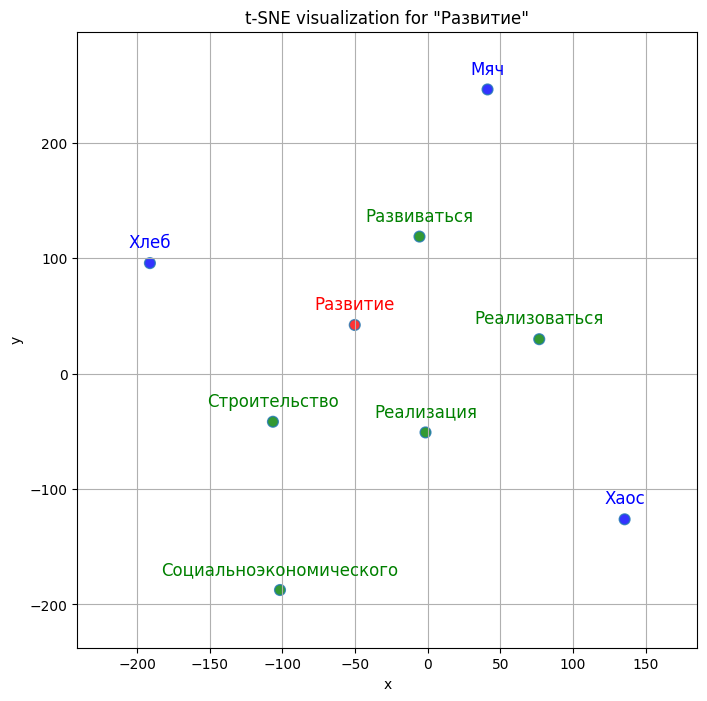

In [78]:
tsne_scatterplot(w2v, 'развитие', ['мяч', 'анархия', 'хаос', 'хлеб'])

Generally, it's not ideally, but logically.

**5.1.2 Using the model**

Word2Vec creates a vector for each word, but a single news article contains more than one word. Therefore, we need to create a single vector for the entire text of the news article. The simplest way is to average the vectors for all words.

In [79]:
df_word2vec = df_train[['split_text', 'bloc']].copy()

df_word2vec.head()

,split_text,bloc
0,"[фото, марина, совина, вооружить, сила, украина, всу, наступление, новый, год, обстрелять, центр, донецк, сообщить, глава, донецкий, народный, республика, днр, денис, пушилин, состояние, предварительный, информация, человек, погибнуть, получить, ранение, отметить, пушилин, сообщать, три, погибнуть, семь, раненый, пострадавшим, оказываться, медицинский, помощь, данным, совместный, центр, контроль, координация, режим, прекращение, огонь, сццк, днр, выпустить, ракета, реактивный, система, залповый, огонь, рсзо, какой, уточняться, время, удар, центр, донецк, погибнуть, военный, корреспондент, получить, ранение, сообщить, оперативный, служба, регион, всу, обстрелять, пятизвёздочный, гостиница, донбасс, палас, военкор, александр, сладков, подтвердить, информация, коллега, подчеркнуть, украинские, военный, преднамеренно, ударить, мирный, квартал, донецк, число, гостиница, донбасс, палас, ни, военный, штаб, ни, расположение, ...]",3
1,"[фото, марина, совина, кандидат, медицинский, наука, врачдиетолог, маргарита, арзуманян, беседа, радио, назвать, полезный, соус, слово, полезный, соус, готовить, дома, добавить, необходимый, приготовление, салат, майонез, калориен, традиционный, рецепт, практически, отсутствовать, вредный, здоровье, ингредиентыспециалист, подчеркнуть, приготовление, майонез, домашний, производство, потребоваться, растительный, масло, желток, лимонный, сок, горчица, небольшой, количество, соль, сахар, соус, промышленный, изготовление, содержать, избыток, соль, различный, пищевой, добавка, отметить, диетолог, арзуманян, добавить, состав, покупной, кетчуп, лишний, организм, соль, пищевой, добавка, крахмал, слово, сделать, томатный, соус, самостоятельно, получиться, продукт, добавить, приготовить, домашний, рецепт, соус, превосходить, купить, магазин, аналог, врачэндокринолог, диетолог, оксана, михалёв, перечислить, самые, вредный, блюдо, обходиться, ни, новогодний, застолье, самым, вредный, ...]",5
2,"[фото, марина, совина, горнолыжный, комплекс, загореться, крылатский, холм, москва, сообщать, издание, канал, площадь, пожар, составлять, квадратный, метр, столб, чёрный, дым, видный, издалёка, место, работать, наряд, мчс, предварительный, данным, пострадавших, житель, район, сообщать, взрыв, территория, комплекс, вероятно, звук, фейерверк, барвихе, загореться, частный, спортивный, комплекс, принадлежать, бизнесмен, михаил, ходорковский, внести, реестр, иноагентов, возгорание, произойти, посёлок, яблоневый, сад, загореться, кровля, спорткомплекс, площадь, квадратный, метр, спорткомплекс, создать, кооператив, семь, дом, проживать, топменеджеры, нефтяной, компания, юкос]",0
3,"[владимир, зеленский, фото, марина, совина, президент, украина, владимир, зеленский, заявить, гражданин, страна, поздно, сделать, выбор, статус, беженец, исполнение, долг, страна, политик, поставить, украинец, выбор, новогодний, обращение, разместить, страница, администрация, знать, прийтись, поставить, вопрос, жертва, победитель, беженец, гражданин, заявить, украинский, лидер, зеленский, заявить, получить, военный, план, год, время, заседание, штаб, верховный, главнокомандующий, политик, привести, никакой, подробность, украинский, лидер, отметить, встреча, заслушать, отчёт, внешний, разведка, документ, говориться, число, общий, военнополитических, ожидание, возможный, событие, мир, добавить]",3
4,"[фото, александр, синицын, январь, год, россия, повыситься, размер, социальный, налоговый, вычет, лечение, тысяча, рубль, поправка, внести, налоговый, кодекс, рф, предельный, сумма, составлять, тысяча, рубль, говориться, официальный, сайт, правовой, информация, лимит, увеличить, тысяча, рубль, входить, совокупность, расход, лечение, исключать, дорогостоящую, медицинский, помощь, никакой, ограничение, образование, физкультурнооздоровительные, услуга, взнос, альтернативный, государственный, пенсия, добровольный, пенсионный, страхование, страхование, жизнь, оплата, независимый, оценка, квалификация, размер, предельный, налоговый, вычет, лечение

In [80]:
df_word2vec['vectors'] = df_word2vec['split_text'].map(TextHandler.get_mean_vector)

df_word2vec.head()

,split_text,bloc,vectors
0,"[фото, марина, совина, вооружить, сила, украина, всу, наступление, новый, год, обстрелять, центр, донецк, сообщить, глава, донецкий, народный, республика, днр, денис, пушилин, состояние, предварительный, информация, человек, погибнуть, получить, ранение, отметить, пушилин, сообщать, три, погибнуть, семь, раненый, пострадавшим, оказываться, медицинский, помощь, данным, совместный, центр, контроль, координация, режим, прекращение, огонь, сццк, днр, выпустить, ракета, реактивный, система, залповый, огонь, рсзо, какой, уточняться, время, удар, центр, донецк, погибнуть, военный, корреспондент, получить, ранение, сообщить, оперативный, служба, регион, всу, обстрелять, пятизвёздочный, гостиница, донбасс, палас, военкор, александр, сладков, подтвердить, информация, коллега, подчеркнуть, украинские, военный, преднамеренно, ударить, мирный, квартал, донецк, число, гостиница, донбасс, палас, ни, военный, штаб, ни, расположение, ...]",3,"[-0.020749934, 0.028708095, 0.119350456, -0.111713976, -0.0034028671, -0.02680946, -0.01298017, 0.15055335, -0.017529966, -0.066494055, -0.16040857, -0.15852408, -0.017398482, -0.06564215, -0.038901623, -0.05005334, -0.10604864, -0.08487258, 0.12748457, 0.011512942, 0.03921044, 0.20764053, 0.09506021, -0.115228996, -0.054377742, 0.02640154, 0.00085218, 0.041435327, -0.015441315, 0.024734754, 0.13758451, -0.17634906, -0.08322337, -0.03760311, -0.04773284, -0.08623175, 0.06596558, -0.03363972, -0.13154928, 0.044444278, -0.047275916, -0.051862746, -0.095845975, -0.021908045, 0.10430326, -0.011624098, -0.020156866, 0.014428614, -0.018977422, -0.11617639, -0.12209646, 0.06368224, 0.007645043, -0.06349869, 0.06392598, -0.12091059, 0.034734562, 0.15636398, -0.00982589, -0.19161741, -0.13132502, 0.05200761, -0.029981876, -0.16317011, 0.10030546, -0.28017303, -0.080542855, 0.023508279, -0.20720208, -0.12918334, -0.08184735, 0.21107112, -0.0038014154, -0.19491419, 0.07252552, 0.11635264, -0.070333175, 0.15427576, 0.06296874, 0.29413015, 0.004910866, -0.15312405, -0.091635525, -0.034209415, -0.02988396, 0.0055216826, 0.091377534, 0.066009894, -0.09566534, 0.1969281, -0.043850597, 0.0704142, -0.047256183, 0.1331199, 0.10287924, 0.07370715, -0.081612356, 0.026535003, -0.15813339, 0.3121898, ...]"
1,"[фото, марина, совина, кандидат, медицинский, наука, врачдиетолог, маргарита, арзуманян, беседа, радио, назвать, полезный, соус, слово, полезный, соус, готовить, дома, добавить, необходимый, приготовление, салат, майонез, калориен, традиционный, рецепт, практически, отсутствовать, вредный, здоровье, ингредиентыспециалист, подчеркнуть, приготовление, майонез, домашний, производство, потребоваться, растительный, масло, желток, лимонный, сок, горчица, небольшой, количество, соль, сахар, соус, промышленный, изготовление, содержать, избыток, соль, различный, пищевой, добавка, отметить, диетолог, арзуманян, добавить, состав, покупной, кетчуп, лишний, организм, соль, пищевой, добавка, крахмал, слово, сделать, томатный, соус, самостоятельно, получиться, продукт, добавить, приготовить, домашний, рецепт, соус, превосходить, купить, магазин, аналог, врачэндокринолог, диетолог, оксана, михалёв, перечислить, самые, вредный, блюдо, обходиться, ни, новогодний, застолье, самым, вредный, ...]",5,"[-0.13731271, -0.21494856, 0.23691991, 0.049211223, -0.013044526, -0.07742877, -0.12334127, 0.14885435, 0.104922086, 0.10975921, -0.16388711, -0.12749726, 0.15331553, -0.13540182, 0.13458261, -0.072338544, -0.35047987, -0.24390382, 0.08421443, 0.05529406, -0.16398728, -0.02854314, 0.15665859, 0.20528932, 0.11963897, -0.019912733, 0.19043192, 0.1362589, -0.1236193, 0.11441438, 0.14241748, -0.052578557, -0.08191041, 0.016026795, -0.067525774, -0.09762134, 0.01242008, 0.002591149, -0.036164843, -0.19890474, -0.12793335, -0.011433793, -0.11754567, 0.08977142, 0.05308121, -0.014807483, 0.014997198, 0.29939845, -0.06551579, 0.1220029, 0.102048606, 0.13833532, -0.11975538, -0.1050055, -0.0715344, -0.1084475, 0.15261735, 0.1793

In [81]:
type(df_word2vec.loc[0, 'vectors'])

numpy.ndarray

In [82]:
# remove rows for which vectors were not calculated (all words were unknown)
df_word2vec = df_word2vec.dropna()

df_word2vec.shape

(242244, 3)

In [83]:
# let's separate each coordinate of the vector into a separate column
# 300 - size of each vector
cols = ['col_' + str(i) for i in range(300)]
df_word2vec[cols] = df_word2vec['vectors'].tolist()

df_word2vec.head()

,split_text,bloc,vectors,col_0,col_1,col_2,col_3,col_4,col_5,col_6,...,col_290,col_291,col_292,col_293,col_294,col_295,col_296,col_297,col_298,col_299
0,"[фото, марина, совина, вооружить, сила, украина, всу, наступление, новый, год, обстрелять, центр, донецк, сообщить, глава, донецкий, народный, республика, днр, денис, пушилин, состояние, предварительный, информация, человек, погибнуть, получить, ранение, отметить, пушилин, сообщать, три, погибнуть, семь, раненый, пострадавшим, оказываться, медицинский, помощь, данным, совместный, центр, контроль, координация, режим, прекращение, огонь, сццк, днр, выпустить, ракета, реактивный, система, залповый, огонь, рсзо, какой, уточняться, время, удар, центр, донецк, погибнуть, военный, корреспондент, получить, ранение, сообщить, оперативный, служба, регион, всу, обстрелять, пятизвёздочный, гостиница, донбасс, палас, военкор, александр, сладков, подтвердить, информация, коллега, подчеркнуть, украинские, военный, преднамеренно, ударить, мирный, квартал, донецк, число, гостиница, донбасс, палас, ни, военный, штаб, ни, расположение, ...]",3,"[-0.020749934, 0.028708095, 0.119350456, -0.111713976, -0.0034028671, -0.02680946, -0.01298017, 0.15055335, -0.017529966, -0.066494055, -0.16040857, -0.15852408, -0.017398482, -0.06564215, -0.038901623, -0.05005334, -0.10604864, -0.08487258, 0.12748457, 0.011512942, 0.03921044, 0.20764053, 0.09506021, -0.115228996, -0.054377742, 0.02640154, 0.00085218, 0.041435327, -0.015441315, 0.024734754, 0.13758451, -0.17634906, -0.08322337, -0.03760311, -0.04773284, -0.08623175, 0.06596558, -0.03363972, -0.13154928, 0.044444278, -0.047275916, -0.051862746, -0.095845975, -0.021908045, 0.10430326, -0.011624098, -0.020156866, 0.014428614, -0.018977422, -0.11617639, -0.12209646, 0.06368224, 0.007645043, -0.06349869, 0.06392598, -0.12091059, 0.034734562, 0.15636398, -0.00982589, -0.19161741, -0.13132502, 0.05200761, -0.029981876, -0.16317011, 0.10030546, -0.28017303, -0.080542855, 0.023508279, -0.20720208, -0.12918334, -0.08184735, 0.21107112, -0.0038014154, -0.19491419, 0.07252552, 0.11635264, -0.070333175, 0.15427576, 0.06296874, 0.29413015, 0.004910866, -0.15312405, -0.091635525, -0.034209415, -0.02988396, 0.0055216826, 0.091377534, 0.066009894, -0.09566534, 0.1969281, -0.043850597, 0.0704142, -0.047256183, 0.1331199, 0.10287924, 0.07370715, -0.081612356, 0.026535003, -0.15813339, 0.3121898, ...]",-0.020750,0.028708,0.119350,-0.111714,-0.003403,-0.026809,-0.012980,...,0.112801,-0.072862,-0.002727,-0.103142,-0.009808,0.055555,-0.069322,0.089179,0.080668,0.114090
1,"[фото, марина, совина, кандидат, медицинский, наука, врачдиетолог, маргарита, арзуманян, беседа, радио, назвать, полезный, соус, слово, полезный, соус, готовить, дома, добавить, необходимый, приготовление, салат, майонез, калориен, традиционный, рецепт, практически, отсутствовать, вредный, здоровье, ингредиентыспециалист, подчеркнуть, приготовление, майонез, домашний, производство, потребоваться, растительный, масло, желток, лимонный, сок, горчица, небольшой, количество, соль, сахар, соус, промышленный, изготовление, содержать, избыток, соль, различный, пищевой, добавка, отметить, диетолог, арзуманян, добавить, состав, покупной, кетчуп, лишний, организм, соль, пищевой, добавка, крахмал, слово, сделать, томатный, соус, самостоятельно, получиться, продукт, добавить, приготовить, домашний, рецепт, соус, превосходить, купить, магазин, аналог, врачэндокринолог, диетолог, оксана, михалёв, перечислить, самые, вредный, блюдо, обходиться, ни, новогодний, застолье, самым, вредный, ...]",5,"[-0.13731271, -0.21494856, 0.23691991, 0.049211223, -0.013044526, -0.07742877, -0.12334127, 0.14885435, 0.104922086, 0.10975921, -0.16388711, -0.12749726, 0.15331553, -0.13540182, 0.13458261, -0.072338544, -0.35047987, -0.24390382, 0.08421443, 0.05529406, -0.16398728, -0.02854314, 0.15665859, 0.20528932, 0.11963897, -0.019912733, 0.19043192, 0.1362589, -0.1236193, 0.11441438, 0.14241748, -0.052578557, -0.08191041, 0.016026795, -0.06

**Logistic regression**

In [84]:
X = df_word2vec.drop(columns=['split_text', 'bloc', 'vectors'])
y = df_word2vec['bloc']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2,
                                                  random_state=42,
                                                  stratify=y
                                                 )

X_train.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_290,col_291,col_292,col_293,col_294,col_295,col_296,col_297,col_298,col_299
153480,0.105565,0.022567,0.117417,0.005346,0.012683,0.016140,0.055896,0.126920,0.081607,-0.001478,...,0.125067,-0.017160,0.057993,-0.092737,-0.117677,0.114931,-0.025846,0.081976,0.094508,0.186575
167150,0.105455,-0.076320,0.068381,-0.036160,-0.175943,-0.032892,0.009621,0.172962,0.179179,0.030709,...,0.095065,-0.134082,-0.051689,-0.171673,-0.063006,0.109848,0.088640,-0.029758,0.093417,-0.011501
23368,0.088235,-0.022828,0.126904,-0.205918,-0.002824,-0.028332,-0.120927,0.093169,-0.084209,-0.013941,...,0.113298,-0.110479,-0.053910,-0.041692,-0.122113,0.117849,-0.004249,0.172224,0.175231,0.101209
132227,-0.028056,-0.092295,0.150253,-0.016704,-0.022121,-0.086491,-0.068137,0.175236,0.114488,0.199433,...,0.046149,-0.039079,0.127835,-0.014910,-0.134152,-0.110114,-0.044915,-0.039309,0.144806,0.200114
12707,0.162140,-0.058376,0.099037,0.005878,-0.088840,0.027245,-0.023932,0.147755,0.095123,-0.047131,...,0.118414,-0.062428,0.169480,-0.088710,-0.141876,-0.057768,-0.079469,0.187615,0.085036,0.169718


In [85]:
y_val.head()

62108     8
189593    0
182314    0
225055    1
116323    1
Name: bloc, dtype: uint8

In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# specify the number of iterations
log_reg = LogisticRegression(max_iter=300, class_weight='balanced',
                             random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_reg_pred_train = log_reg.predict(X_train_scaled)

# metrics on the train set
print(classification_report(y_train, log_reg_pred_train))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88     51143
           1       0.92      0.93      0.93     36860
           2       0.93      0.96      0.95     26308
           3       0.91      0.93      0.92     34893
           4       0.98      1.00      0.99     11138
           5       0.94      0.99      0.96      7233
           6       0.92      1.00      0.96      3199
           7       0.93      0.98      0.96     11051
           8       0.90      0.97      0.93     11970

    accuracy                           0.92    193795
   macro avg       0.93      0.96      0.94    193795
weighted avg       0.92      0.92      0.92    193795



In [87]:
log_reg_pred_val = log_reg.predict(X_val_scaled)

# metrics on the val set
print(classification_report(y_val, log_reg_pred_val))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88     12786
           1       0.92      0.93      0.92      9215
           2       0.93      0.96      0.94      6577
           3       0.91      0.93      0.92      8724
           4       0.98      0.99      0.98      2784
           5       0.94      0.97      0.96      1808
           6       0.90      0.99      0.94       800
           7       0.93      0.97      0.95      2763
           8       0.88      0.96      0.92      2992

    accuracy                           0.92     48449
   macro avg       0.92      0.95      0.94     48449
weighted avg       0.92      0.92      0.92     48449



At this intermediate stage the results are already worse than for the baseline.

Now we transform the test data.

In [88]:
X_test = df_test['content']

gen = (re.sub(r'[^а-яё\s]', '', row.lower()) for row in X_test)
try:
    list_text = [TextHandler.tokenize_text(doc) for doc in nlp.pipe(gen,
                                                                    batch_size=500,
                                                                    n_process=cores - 1)]
except Exception as e:
    print(e)

print(len(list_text))

26275


We have a missing value, we need to take this into account in the get_mean_vector function.

In [89]:
X_test = pd.DataFrame({'content': list_text}, index=X_test.index)
X_test['vectors'] = X_test['content'].map(TextHandler.get_mean_vector)

X_test.head()

,content,vectors
0,"[фото, фонтанкаруподелитьсяэксминистру, оборона, днр, игорь, стрелкову, гиркин, прийтись, уйти, подполье, встретиться, петербург, тридцатью, поклонник, создание, нужный, атмосфера, задействовать, автозак, росгвардии, кинолог, собака, четыре, полицейский, машина, чертовый, дюжина, силовик, последний, семь, год, стрелок, гиркин, выступать, петербург, столь, перестать, событие, предыдущий, раз, собирать, аншлаг, листве, январь, книжный, лавка, листва, литейный, проспект, принадлежать, издательство, чёрный, сотня, название, содержаться, указание, правый, характер, сподвижник, считать, общество, патриот, регулярный, основа, проходить, встреча, читатель, военкор, владлен, татарский, приходить, сюда, час, взорванной, университетский, набережная, бомба, листве, дарья, дугин, весна, выступать, известный, путч, марш, пригожина, мятежник, полковник, квачков, фото, телеграмканал, листва, петербургфото, телеграмканал, листва, петербургподелитьсякак, правило, рядовой, встреча, листве, ...]","[0.031759698, 0.029759737, 0.13213441, 0.003797444, -0.019639356, -0.048840493, 0.07152713, 0.16447733, 0.024340091, -0.031446047, -0.1168556, -0.10240768, 0.004519731, -0.027367463, -0.05397065, -0.09082269, -0.14767884, -0.09018327, 0.07556104, -0.052182417, -0.095095806, 0.065570764, 0.11150233, -0.019238288, 0.04558969, 0.12891582, 0.08318301, 0.09198098, -0.05113956, 0.07005939, 0.013156309, -0.053528197, -0.08959819, -0.1349202, -0.019423435, -0.039273255, -0.02037217, -0.057864547, -0.16765705, -0.10026704, -0.058040846, -0.035723463, -0.08144431, 0.044391192, 0.016859662, 0.041065875, 0.052008238, 0.1058877, -0.088179775, 0.011528855, -0.02036408, 0.10269631, -0.039951224, -0.16718353, 0.0038164444, -0.06859807, 0.08498828, 0.10942286, -0.037826743, -0.11208839, -0.12120132, 0.0057951417, -0.034400746, -0.11426014, 0.1267151, -0.16969779, -0.07768068, -0.022617638, -0.15221551, -0.020233497, -0.07411282, 0.1550157, -0.06998206, -0.14035335, 0.084908, 0.043842897, -0.068873286, 0.08023757, 0.046469364, 0.22995667, -0.079726085, -0.1774526, -0.027083892, 0.0787647, 0.04194497, 0.07059866, 0.038411118, 0.11253031, -0.013237603, 0.14634795, -0.08820001, 0.100489065, -0.041601345, 0.1090012, 0.066590205, 0.058919445, -0.12696148, 0.03948716, -0.10828329, 0.27461427, ...]"
1,"[февраль, год, пушкинский, район, санктпетербурга, введён, эксплуатация, новый, малоэтажный, жилой, комплекс, сведение, объект, капитальный, строительство, внести, специальный, кадастр, недвижимостифото, ооо, сз, терминалресурсподелитьсякадастровый, учёт, осуществлять, федеральный, служба, государственный, регистрация, кадастр, картография, росреестр, поставить, дом, кадастровый, учёт, означать, внести, база, основный, характеристика, наименование, адрес, назначение, этажность, ситуационный, план, кадастровый, номер, оформление, право, собственность, объект, недвижимость, последующий, распоряжение, собстве, договору, куплипродажи, готовый, квартира, застройщик, распространяться, программа, льготный, ипотека, строящиеся, объектыквартиры, пушкинский, район, санктпетербург, ул, кокколевская, бц, перспектива, отдел, продажа, образцовый, квартал, справка, компания, ооо, сз, терминалресурсжк, образцовый, квартал, образцовый, квартал, образцовый, квартал, образцовый, квартал, образцовый, квартал, застройщик, ооо, сз, терминалресурс, проектный, декларация, сайт, ...]","[0.073817916, -0.0067458176, -0.031220462, -0.07862939, 0.0086800065, 0.018456336, -0.013957414, 0.16652872, 0.12348304, -0.041761145, -0.12628841, -0.05089946, -0.07930325, -0.1262721, -0.12864366, -0.15436769, -0.27506346, -0.118632056, 0.011755925, 0.024446545, -0.20550795, 0.026536794, 0.16258313, -0.055149958, -0.036782153, 0.038675003, 0.19511288, -0.07666401, -0.00075717364, 0.08620397, 0.0066039655, -0.10199089, -0.026572816, -0.21627593, -0.053780027, 0.01359924, -0.04288018, -0.028975079, -0.17141557, -0.052174564, 0.012540403, -0.11549623, -0.2668013, -0.062938124, 0.052897636, -0.037748188, 

In [90]:
X_test.isnull().sum()

content    1
vectors    1
dtype: int64

In [91]:
cols = ['col_' + str(i) for i in range(300)]

# we need to handle correctly calculated vectors and NaN
# differently, let's create 2 dataframes. We need to save the
# indices for further work
X_test_correct = X_test[X_test['vectors'].notnull()]
X_test_correct[cols] = X_test_correct['vectors'].tolist()
idx_correct = X_test_correct.index

X_test_incorrect = X_test[X_test['vectors'].isnull()]
idx_incorrect = X_test_incorrect.index

X_test_correct.head()

,content,vectors,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,...,col_290,col_291,col_292,col_293,col_294,col_295,col_296,col_297,col_298,col_299
0,"[фото, фонтанкаруподелитьсяэксминистру, оборона, днр, игорь, стрелкову, гиркин, прийтись, уйти, подполье, встретиться, петербург, тридцатью, поклонник, создание, нужный, атмосфера, задействовать, автозак, росгвардии, кинолог, собака, четыре, полицейский, машина, чертовый, дюжина, силовик, последний, семь, год, стрелок, гиркин, выступать, петербург, столь, перестать, событие, предыдущий, раз, собирать, аншлаг, листве, январь, книжный, лавка, листва, литейный, проспект, принадлежать, издательство, чёрный, сотня, название, содержаться, указание, правый, характер, сподвижник, считать, общество, патриот, регулярный, основа, проходить, встреча, читатель, военкор, владлен, татарский, приходить, сюда, час, взорванной, университетский, набережная, бомба, листве, дарья, дугин, весна, выступать, известный, путч, марш, пригожина, мятежник, полковник, квачков, фото, телеграмканал, листва, петербургфото, телеграмканал, листва, петербургподелитьсякак, правило, рядовой, встреча, листве, ...]","[0.031759698, 0.029759737, 0.13213441, 0.003797444, -0.019639356, -0.048840493, 0.07152713, 0.16447733, 0.024340091, -0.031446047, -0.1168556, -0.10240768, 0.004519731, -0.027367463, -0.05397065, -0.09082269, -0.14767884, -0.09018327, 0.07556104, -0.052182417, -0.095095806, 0.065570764, 0.11150233, -0.019238288, 0.04558969, 0.12891582, 0.08318301, 0.09198098, -0.05113956, 0.07005939, 0.013156309, -0.053528197, -0.08959819, -0.1349202, -0.019423435, -0.039273255, -0.02037217, -0.057864547, -0.16765705, -0.10026704, -0.058040846, -0.035723463, -0.08144431, 0.044391192, 0.016859662, 0.041065875, 0.052008238, 0.1058877, -0.088179775, 0.011528855, -0.02036408, 0.10269631, -0.039951224, -0.16718353, 0.0038164444, -0.06859807, 0.08498828, 0.10942286, -0.037826743, -0.11208839, -0.12120132, 0.0057951417, -0.034400746, -0.11426014, 0.1267151, -0.16969779, -0.07768068, -0.022617638, -0.15221551, -0.020233497, -0.07411282, 0.1550157, -0.06998206, -0.14035335, 0.084908, 0.043842897, -0.068873286, 0.08023757, 0.046469364, 0.22995667, -0.079726085, -0.1774526, -0.027083892, 0.0787647, 0.04194497, 0.07059866, 0.038411118, 0.11253031, -0.013237603, 0.14634795, -0.08820001, 0.100489065, -0.041601345, 0.1090012, 0.066590205, 0.058919445, -0.12696148, 0.03948716, -0.10828329, 0.27461427, ...]",0.031760,0.029760,0.132134,0.003797,-0.019639,-0.048840,0.071527,0.164477,...,0.088007,-0.089733,0.103069,-0.089930,-0.082812,0.071368,0.008930,0.084028,0.140213,0.109328
1,"[февраль, год, пушкинский, район, санктпетербурга, введён, эксплуатация, новый, малоэтажный, жилой, комплекс, сведение, объект, капитальный, строительство, внести, специальный, кадастр, недвижимостифото, ооо, сз, терминалресурсподелитьсякадастровый, учёт, осуществлять, федеральный, служба, государственный, регистрация, кадастр, картография, росреестр, поставить, дом, кадастровый, учёт, означать, внести, база, основный, характеристика, наименование, адрес, назначение, этажность, ситуационный, план, кадастровый, номер, оформление, право, собственность, объект, недвижимость, последующий, распоряжение, собстве, договору, куплипродажи, готовый, квартира, застройщик, распространяться, программа, льготный, ипотека, строящиеся, объектыквартиры, пушкинский, район, санктпетербург, ул, кокколевская, бц, перспектива, отдел, продажа, образцовый, квартал, справка, компания, ооо, сз, терминалресурсжк, образцовый, квартал, образцовый, квартал, образцовый, квартал, образцовый, квартал, образцовый, квартал, застройщик, ооо, сз, терминалресурс, проектный, декларация, сайт, ...]","[0.073817916, -0.0067458176, -0.031220462, -0.07862939, 0.0086800065, 0.018456336, -0.013957414, 0.16652872, 0.12348304, -0.041761145, -0.12628841, -0.05089946, -0.07930325, -0.1262721, -0.12864366, -0.15436769, -0.27506346, -0.118632056, 0.011755925, 0.024446545, -0.20550795, 0.026536794, 0.16258313, -0.0

In [92]:
idx_correct

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       26265, 26266, 26267, 26268, 26269, 26270, 26271, 26272, 26273, 26274],
      dtype='int64', length=26274)

In [93]:
idx_incorrect

Index([24566], dtype='int64')

Now we'll get predictions only for X_test_correct, and we'll insert them into the submission later. For idx_incorrect, we'll fill the submission with one of the target values (for example, 0).

In [94]:
X_test = X_test_correct.drop(columns=['content', 'vectors'])
X_test_scaled = scaler.transform(X_test)

del df_word2vec, X_test_correct, X_test_incorrect
clear_memory()

In [95]:
log_reg_pred_w2v = log_reg.predict(X_test_scaled)

submission_log_reg_w2v = submission_template.copy()
submission_log_reg_w2v.loc[idx_correct, 'topic'] = log_reg_pred_w2v
submission_log_reg_w2v.loc[idx_incorrect, 'topic'] = 0
submission_log_reg_w2v.to_csv('submission_log_reg_w2v.csv', index=False)

print('✅ submission_log_reg_w2v.csv created successfully!')

✅ submission_log_reg_w2v.csv created successfully!


We got accuracy = 0.77787, which is worse than the baseline. Therefore, we will not attempt to tune the hyperparameters and will instead try a different vectorization method.

**5.2 BERT (RuBERT)**

We will use the Russian-language BERT (RuBERT). There's also a 'bert-base-multilingual-cased' model, but it's worse for Russian language.

RuBERT only has the cased model.

In [96]:
tokenizer_class = transformers.AutoTokenizer
model_class = transformers.AutoModel
model_name = 'DeepPavlov/rubert-base-cased'

tokenizer = tokenizer_class.from_pretrained(model_name,
                                            # don't convert to lowercase
                                            do_lower_case=False,
                                            padding_side='right',
                                            trunkation_side='right'
                                           )
model = model_class.from_pretrained(model_name)

INFO - 15:34:56: HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
WARNING - 15:34:56: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
INFO - 15:34:56: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/config.json "HTTP/1.1 200 OK"
INFO - 15:34:56: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

INFO - 15:34:56: HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO - 15:34:56: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/tokenizer_config.json "HTTP/1.1 200 OK"
INFO - 15:34:56: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

INFO - 15:34:56: HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO - 15:34:56: HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO - 15:34:56: HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/vocab.txt "HTTP/1.1 307 Temporary Redirect"
INFO - 15:34:56: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/vocab.txt "HTTP/1.1 200 OK"
INFO - 15:34:56: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/vocab.txt "HTTP/1.1 200 OK"


...

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

INFO - 15:35:05: HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
INFO - 15:35:05: HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased "HTTP/1.1 200 OK"
INFO - 15:35:05: HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/commits/main "HTTP/1.1 200 OK"
INFO - 15:35:05: HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/discussions?p=0 "HTTP/1.1 200 OK"
INFO - 15:35:05: HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/commits/refs%2Fpr%2F4 "HTTP/1.1 200 OK"
INFO - 15:35:05: HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/refs%2Fpr%2F4/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO - 15:35:05: HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/refs%2Fpr%2F4/model.safetensors "HTTP/1.1 302 Found"
INFO - 15:35:05: HTTP Reques

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [97]:
tokenizer

BertTokenizer(name_or_path='DeepPavlov/rubert-base-cased', vocab_size=119547, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [98]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

Let's see how tokenizer works:

In [99]:
text = ['Сегодня хороший день', 'но не идеальный']

# we can use __call__ method:
# add_special_tokens - whether or not to add special tokens
#   when encoding the sequences;
# padding - activates and controls padding [PAD]. In the
#   following, these positions are invisible in self-attention
#   thanks to attention_mask - it marks 1 as a real token, 0 as padding;
# truncation - activates and controls truncation (a process for
#   automatically truncating overly long texts to a size that BERT can handle);
# max_length - controls the maximum length to use by one of the truncation/padding
#   parameters;
# return_tensors - if set, will return tensors instead of list of python integers
encoded_input = tokenizer(text,
                          add_special_tokens=True,
                          padding='max_length',
                          truncation=True,
                          max_length=8
                         )

# tokenizer returns BatchEncoding object
print(encoded_input)
print()
print(encoded_input.input_ids) # list of token ids to be fed to a model
# list of indices specifying which tokens should be attended to by the model
print(encoded_input.attention_mask)
print(encoded_input.tokens()) # tokens

{'input_ids': [[101, 20530, 35592, 6622, 102, 0, 0, 0], [101, 3435, 1699, 86596, 102, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 0, 0, 0], [1, 1, 1, 1, 1, 0, 0, 0]]}

[[101, 20530, 35592, 6622, 102, 0, 0, 0], [101, 3435, 1699, 86596, 102, 0, 0, 0]]
[[1, 1, 1, 1, 1, 0, 0, 0], [1, 1, 1, 1, 1, 0, 0, 0]]
['[CLS]', 'Сегодня', 'хороший', 'день', '[SEP]', '[PAD]', '[PAD]', '[PAD]']


In [100]:
# tokenizer.encode - converts the original text (string) into a numeric
# format. Each token is assigned a unique numeric identifier (ID) from the
# BERT dictionary. Special tokens are also added: [CLS] (ID 101) at
# the beginning of the text; [SEP] (ID 102) at the end of the text
# (separator). Finally, the method returns a list of integers (IDs)
tokenizer.encode(text, add_special_tokens=True)

[[101, 20530, 35592, 6622, 102], [101, 3435, 1699, 86596, 102]]

In [101]:
# tokenizer.decode - performs the inverse transformation
# skip_special_tokens allows to skip special tokens
print(tokenizer.decode([[101, 20530, 35592, 6622, 102], [101, 3435, 1699, 86596, 102]],
                       skip_special_tokens=True))
print(tokenizer.decode([[101, 20530, 35592, 6622, 102], [101, 3435, 1699, 86596, 102]],
                       skip_special_tokens=False))

['Сегодня хороший день', 'но не идеальный']
['[CLS] Сегодня хороший день [SEP]', '[CLS] но не идеальный [SEP]']


Transformer model tokenizers typically don't require manual punctuation removal, stopword removal, or case conversion: the tokenizers are already trained on raw text and expect roughly the same format.

Therefore, we'll only perform light normalization of HTML breaks and whitespace.

Most of the lines contain the word 'фото' (caption under the photo), it is generally not informative, so it can be removed or left.

In [102]:
df_train['cleaned_text'] = df_train['text'].map(TextHandler.clean_for_transformer)

df_train['cleaned_text'].head()

0    Фото: Keystone Press Agency / Globallookpress.com Марина Совина Вооруженные силы Украины (ВСУ) сразу после наступления Нового года обстреляли центр Донецка. Об этом сообщил глава Донецкой народной республики (ДНР) Денис Пушилин. По состоянию на 02:00, по предварительной информации, 4 человека погибли, 13 получили ранения, отметил Пушилин. До этого он сообщал о трех погибших и семи раненых, всем пострадавшим оказывается медицинская помощь. По данным Совместного центра по контролю и координации режима прекращения огня (СЦЦК) ДНР, было выпущено 15 ракет из реактивных систем залпового огня (РСЗО), из каких именно, не уточняется. Во время удара по центру Донецка погиб военный корреспондент, еще один получил ранения, сообщили в оперативных службах региона. ВСУ обстреляли пятизвездочную гостиницу «Донбасс Палас». Военкор Александр Сладков подтвердил информацию о коллегах. Он подчеркнул, что украинские военные преднамеренно ударили по мирным кварталам Донецка, в том числе по гостинице «До

In [103]:
# max length of our texts
max_len = df_train['cleaned_text'].str.len().max()
print(f'Maximum length of texts: {max_len}')

# 95th percentile
percentile_95 = df_train['cleaned_text'].str.len().quantile(0.95)
print(f'95th percentile of texts length: {percentile_95}')

Maximum length of texts: 33023
95th percentile of texts length: 2173.0


Max_length for RuBERT - 512.

The embedding dimension of RuBERT - 768.

**To store the maximum amount of information, we will use the maximum context length (512).**

We have a large dataframe, so we need to split it into batches.

First, let's test on a small batch how the model works and what it returns.

We will use GPU (T4 x 2) for training models. PyTorch here doesn't support GPU P100.

To parallelize computations between two T4, we can use torch.nn.DataParallel. It automatically divides the batch between the specified devices, copies the model to them, and synchronizes gradients at each step.

**torch.nn.DataParallel is considered a deprecated method for multiprocessor training. DistributedDataParallel (DDP) is recommended instead, but we will use DataParallel due to its simpler setup.**

In [104]:
print(f'CUDA is available: {torch.cuda.is_available()}')
print(f'Number of devices: {torch.cuda.device_count()}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.device_count() > 1:
    # device_ids - CUDA devices (default: all devices)
    model = nn.DataParallel(model)

model = model.to(device)

CUDA is available: True
Number of devices: 2


In [105]:
if torch.cuda.is_available():
    !nvidia-smi

Tue Jun 30 15:35:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             25W /   70W |     839MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [106]:
batch = df_train['cleaned_text'][:8].tolist()

encoded_input = tokenizer(batch,
                          add_special_tokens=True,
                          padding='max_length',
                          truncation=True,
                          max_length=512,
                          return_tensors='pt'
                         ).to(device)

model.eval()
with torch.no_grad():
    # this model is also a PyTorch torch.nn.Module;
    # The BertModel forward method, overrides the __call__ special method;
    # model takes input_ids, attention_mask and token_type_ids (and others)
    #  arguments, so we can unpack the encoded_input
    outputs = model(**encoded_input)

# the tokenizer returns tensors with torch.int64 dtype
print(f'input_ids dtype - {encoded_input["input_ids"].dtype}')
print(f'token_type_ids dtype - {encoded_input["token_type_ids"].dtype}')
print(f'attention_mask dtype - {encoded_input["attention_mask"].dtype}')

print()
# last_hidden_state - sequence of hidden-states at the output of the last
# layer of the model
outputs.last_hidden_state.shape
# the same
# outputs['last_hidden_state'].shape
# outputs[0].shape

input_ids dtype - torch.int64
token_type_ids dtype - torch.int64
attention_mask dtype - torch.int64



torch.Size([8, 512, 768])

**BertForSequenceClassification**

We can use the ready-made Bert Model transformer with a sequence classification head on top (a linear layer on top of the pooled output). The model is already pre-trained, and we can further train it using our texts. We can also extract text embeddings from it later to feed into other ML models.

Training this model will take a long time.

Let's write a class with frequently used functions.

In [107]:
class WorkWithTransformers:
    '''
    A class with frequently used functions for transformers
    '''
    
    @staticmethod
    def tokenize_text(texts):
        encoding = tokenizer(texts,
                             add_special_tokens=True,
                             padding='max_length',
                             truncation=True,
                             max_length=512,
                             return_tensors='pt'
                            )
        return encoding

    @staticmethod
    def predict(model, dataloader):
        # an empty list for results
        res = []
    
        model.eval()
        for batch in tqdm(dataloader):
            encodings_batch = WorkWithTransformers.tokenize_text(batch)
            encodings_batch.to(device)
            
            with torch.no_grad():
                outputs = model(**encodings_batch)
                # outputs.logits - scores before SoftMax
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                res.extend(preds.tolist())
    
        return res

    @staticmethod
    def get_embeddings(model, device, dataloader, pooling):
        # pooling - method for obtaining embeddings ('CLS' or 'Mean')
            
        embeddings = []
        
        model.eval()
        with torch.no_grad():
            for batch in tqdm(dataloader):
                batch.to(device)
                # output_hidden_states=True returns tuple of torch.FloatTensor - one for
                # the output of the embeddings, if the model has an embedding layer + one for
                # the output of each layer of shape (batch_size, 512, 768)
                outputs = model(**batch, output_hidden_states=True)
    
                # get all hidden layers
                # tuple contains: (input_embeddings, layer_1, layer_2, ..., layer_12)
                hidden_states = outputs.hidden_states
                # shape: (batch_size, 512, 768)
                last_hidden_state = hidden_states[-1]
                    
                if pooling == 'CLS':
                    # cls_embedding - shape (batch_size, 768)
                    cls_embedding = last_hidden_state[:, 0, :].cpu().numpy()
                    embeddings.append(cls_embedding)
                        
                elif pooling == 'Mean':
                    # attention_mask - shape (batch_size, 512)
                    attention_mask = batch.attention_mask 
                    # mask_expanded - shape (batch_size, 512, 768)
                    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()       
                    # sum_embedings - shape (batch_size, 768)
                    sum_embedings = torch.sum(last_hidden_state * mask_expanded, dim=1)
                    # to avoid division by zero
                    # sum_mask - shape (batch_size, 768)
                    sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
                    # mean_pooling_embedding - shape (batch_size, 768)
                    mean_pooling_embedding = (sum_embedings / sum_mask).cpu().numpy()
                    embeddings.append(mean_pooling_embedding)
            
            # we combine all the batches
            return np.vstack(embeddings)

Class for the inference:

In [108]:
class TextDataset(data.Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __getitem__(self, item):
        return self.texts[item]

    def __len__(self):
        return len(self.texts)

We convert data from a dataframe to an optimized HF dataset format (internally uses the Apache Arrow format, which ensures high data processing speed and saves RAM).

In [109]:
ds = Dataset.from_pandas(df_train[['cleaned_text', 'bloc']])

print(ds)
print()
# internal data structure of the dataset
print(ds.features)

Dataset({
    features: ['cleaned_text', 'bloc'],
    num_rows: 242244
})

{'cleaned_text': Value('string'), 'bloc': Value('uint8')}


In [110]:
# to stratify by class, the column must be of type ClassLabel
ds = ds.class_encode_column('bloc')

split_ds = ds.train_test_split(test_size=0.2,
                               stratify_by_column='bloc',
                               seed=42
                              )
train_ds = split_ds['train']
val_ds = split_ds['test']

# we change the name of the column with the target, since the model
# expects the name 'labels'
train_ds = train_ds.rename_column('bloc', 'labels')
val_ds = val_ds.rename_column('bloc', 'labels')

train_ds

Stringifying the column:   0%|          | 0/242244 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/242244 [00:00<?, ? examples/s]

Dataset({
    features: ['cleaned_text', 'labels'],
    num_rows: 193795
})

In [111]:
val_ds

Dataset({
    features: ['cleaned_text', 'labels'],
    num_rows: 48449
})

Information from Google:

**NVIDIA Tesla T4 does not support BF16 calculations in hardware. Using BF16 on this card is only possible in emulation mode, where calculations are effectively converted to float32. This significantly reduces performance.**

**Even though BF16 support is indicated here, we will be using FP16.**

In [112]:
if torch.cuda.is_available():
    print(torch.cuda.is_bf16_supported())

True


Trainer class performs Data Parallelism (DDP) by default.

In [113]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_name = 'DeepPavlov/rubert-base-cased'
tokenizer = tokenizer_class.from_pretrained(model_name,
                                            do_lower_case=False,
                                            padding_side='right',
                                            trunkation_side='right'
                                           )
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(topics), # number of classes
    problem_type='single_label_classification' # multi-class classification
    )

# # if we use parallelism (it's difficult to configure memory allocation)
# if torch.cuda.device_count() > 1:
#     model = nn.DataParallel(model)

model = model.to(device)

def tokenize(example, tokenizer):
  # example for the datasets object is a dictionary where the keys are the column
  # names. If the map function's parameter is batched=True, the function should accept
  # a dictionary of lists (batch) and return a dictionary of lists
  return tokenizer(example['cleaned_text'],
                   add_special_tokens=True,
                   padding='max_length',
                   truncation=True,
                   max_length=512,
                   return_tensors='pt'
                  )
    

# delete the column 'cleaned_text'
train_ds_tokenized = train_ds.map(lambda example: tokenize(example, tokenizer),
                                  remove_columns=['cleaned_text'],
                                  batched=True, batch_size=512,
                                  num_proc=cores - 1)
val_ds_tokenized = val_ds.map(lambda example: tokenize(example, tokenizer),
                              remove_columns=['cleaned_text'],
                              batched=True, batch_size=512,
                              num_proc=cores - 1)

# defining metrics for evaluation
# function must take an EvalPrediction and return a
# dictionary string to metric values
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    # use 'weighted' for a multi-class classification
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1_weighted': f1}


# setting up training parameters
training_args = TrainingArguments(
    output_dir='./rubert_news_classifier', # directory to save
    per_device_train_batch_size=16, # the batch size per device
    num_train_epochs=5, # number of epochs
    learning_rate=5e-5, # initial learning rate of the optimizer (default)
    warmup_steps=500,
    # weight decay coefficient applied by the optimizer (not the loss function)
    weight_decay=0.01,
    # number of update steps to accumulate gradients before performing a
    # backward/update pass. Can be increased if there is not enough memory
    gradient_accumulation_steps=1,
    fp16=torch.cuda.is_available(),
    logging_strategy='epoch',
    report_to='none', # disable wandb/tensorboard for clarity
    eval_strategy='epoch', # evaluation after each epoch
    per_device_eval_batch_size=16, # the batch size per device for evaluation
    save_strategy='epoch', # saving after each epoch
    save_total_limit=1, # save only 1 best model
    load_best_model_at_end=True, # load the best model by metric
    metric_for_best_model='accuracy',
    seed=42,
    dataloader_num_workers=cores - 1
)

trainer = Trainer(model=model,
                  args=training_args,
                  # torch.utils.data.Dataset | torch.utils.data.IterableDataset | datasets.Dataset
                  train_dataset=train_ds_tokenized,
                  eval_dataset=val_ds_tokenized,
                  # function that will be used to compute metrics at evaluation
                  compute_metrics=compute_metrics,
                  # early stopping
                  callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
                 )

INFO - 15:36:06: HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO - 15:36:06: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/config.json "HTTP/1.1 200 OK"
INFO - 15:36:06: HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO - 15:36:06: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/tokenizer_config.json "HTTP/1.1 200 OK"
INFO - 15:36:06: HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO - 15:36:06: HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/tree/main?recursive=true&expand=

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Map (num_proc=3):   0%|          | 0/193795 [00:00<?, ? examples/s]

Map (num_proc=3):   0%|          | 0/48449 [00:00<?, ? examples/s]

In [114]:
train_ds_tokenized.features

{'labels': ClassLabel(names=['0', '1', '2', '3', '4', '5', '6', '7', '8']),
 'input_ids': List(Value('int32')),
 'token_type_ids': List(Value('int8')),
 'attention_mask': List(Value('int8'))}

In [115]:
# trainer.train()

In [116]:
# # evaluation of the final model
# metrics = trainer.evaluate()

# metrics

5 training epochs were specified, but early stopping occurred after 3 epochs (the best model - after first epoch).

Loading a previously saved model:

In [117]:
path = '/kaggle/input/models/romaneyvazov/bert-trained/transformers/default/1'
bert = transformers.AutoModelForSequenceClassification.from_pretrained(path)

bert = bert.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Let's make a prediction for new texts.

**If the model is wrapped in nn.DataParallel, the pipeline will not work! Since the model is wrapped, you can't access its original attributes (such as model.config or additional methods) directly. They must be accessed through .module.**

In [118]:
pipe = pipeline(task='text-classification',
                model=bert,
                tokenizer=tokenizer,
                device=device)

texts = ['Путин подписал новый закон о налогах',
         'Apple представила iPhone 15',
         'Построили новый ТЦ в Москве',
         'За границу ездить очень опасно']

# dictionary of the form "topic number": "topic"
id2topic = {v: k for k, v in topics.items()}

for text, pred in zip(texts, pipe(texts, truncation=True, max_length=128)):
    print(text)
    print('prediction:', pred)
    print(f'Topic: {id2topic[int(pred['label'][-1])]}')
    print('-' * 100)

Путин подписал новый закон о налогах
prediction: {'label': 'LABEL_1', 'score': 0.5738871097564697}
Topic: Экономика
----------------------------------------------------------------------------------------------------
Apple представила iPhone 15
prediction: {'label': 'LABEL_8', 'score': 0.997346043586731}
Topic: Наука и техника
----------------------------------------------------------------------------------------------------
Построили новый ТЦ в Москве
prediction: {'label': 'LABEL_1', 'score': 0.6566041111946106}
Topic: Экономика
----------------------------------------------------------------------------------------------------
За границу ездить очень опасно
prediction: {'label': 'LABEL_0', 'score': 0.49265822768211365}
Topic: Общество/Россия
----------------------------------------------------------------------------------------------------


Now we can make a prediction for the test data.

In [119]:
# with preprocessing
X_test = df_test['content'].map(TextHandler.clean_for_transformer).tolist()

test_dataset = TextDataset(X_test)
# shuffle=False to order the predictions
test_dataloader = data.DataLoader(test_dataset, batch_size=256,
                                  shuffle=False, num_workers=cores - 1)
bert_pred = WorkWithTransformers.predict(bert, test_dataloader)

bert_pred[:10]

100%|██████████| 103/103 [13:05<00:00,  7.62s/it]


[2, 1, 4, 1, 4, 3, 2, 3, 3, 3]

In [120]:
submission_bert = submission_template.copy()
submission_bert.loc[:, 'topic'] = bert_pred
submission_bert.to_csv('submission_bert.csv', index=False)

print('✅ submission_bert.csv created successfully!')

✅ submission_bert.csv created successfully!


We got accuracy = 0.79195 when training the BertForSequenceClassification model for 3 epochs. Weak result.

**5.3 Obtaining BERT embeddings for other models**

Another option is to use the output from the final BERT layer to feed other models for classification.

There are two options here too:

1. CLS pooling - extracting the output vector corresponding to the [CLS] token prepended to each text before feeding it to the model. The model is trained so that this initial token accumulates the overall semantic meaning of the entire sentence. [CLS] is primarily used for classification tasks, so the vector ideally reflects the overall meaning of the sentence.

2. Mean pooling - mathematical operation that averages the vector representations of all tokens in the text (excluding paddings). It creates a single fixed-length vector for the entire sentence or document that reflects its overall semantic meaning. Mean pooling often shows better results and is more reliable in inferring semantics.

In [121]:
clear_memory()

In [122]:
batch_size = 128

# # if we use parallelism (it's difficult to configure memory allocation)
# if torch.cuda.device_count() > 1:
#     bert = nn.DataParallel(bert)

bert = bert.to(device)

# if we use FP16 (acceleration)
# if device.type == 'cuda':
#     # equivalent to tensor.to(torch.float16)
#     bert = bert.half()

train_dataset = TextDataset(df_train['cleaned_text'].tolist())
# shuffle=False to order the predictions
# collate_fn - takes a list of individual elements of a dataset
# and combines them into a single batch, ready to be sent to the model
train_dataloader = data.DataLoader(train_dataset,
                                   batch_size=batch_size,
                                   shuffle=False,
                                   collate_fn=WorkWithTransformers.tokenize_text,
                                   num_workers=cores - 1
                                  )

# test_dataset is defined above
test_dataloader = data.DataLoader(test_dataset,
                                  batch_size=batch_size,
                                  shuffle=False,
                                  collate_fn=WorkWithTransformers.tokenize_text,
                                  num_workers=cores - 1
                                 )

BertForSequenceClassification has extra layers so embeddings are extracted differently than usual (see get_embeddings function).

We specify output_hidden_states=True to get the hidden states of the model at the output of each layer.

In [123]:
# embeddings_train_cls_pooling = WorkWithTransformers.get_embeddings(bert,
#                                                                    device,
#                                                                    train_dataloader,
#                                                                    pooling='CLS')
# embeddings_test_cls_pooling = WorkWithTransformers.get_embeddings(bert,
#                                                                   device,
#                                                                   test_dataloader,
#                                                                   pooling='CLS')
# embeddings_train_mean_pooling = WorkWithTransformers.get_embeddings(bert,
#                                                                     device,
#                                                                     train_dataloader,
#                                                                     pooling='Mean')
# embeddings_test_mean_pooling = WorkWithTransformers.get_embeddings(bert,
#                                                                    device,
#                                                                    test_dataloader,
#                                                                    pooling='Mean')

# print(embeddings_train_cls_pooling.shape)
# print(embeddings_test_cls_pooling.shape)
# print(embeddings_train_mean_pooling.shape)
# print(embeddings_test_mean_pooling.shape)

Let's save the resulting embeddings:

In [124]:
# np.save('embeddings_train_cls_pooling.npy', embeddings_train_cls_pooling)
# np.save('embeddings_test_cls_pooling.npy', embeddings_test_cls_pooling)
# np.save('embeddings_train_mean_pooling.npy', embeddings_train_mean_pooling)
# np.save('embeddings_test_mean_pooling.npy', embeddings_test_mean_pooling)

Loading a previously saved embeddings:

In [125]:
embeddings_train_cls_pooling = np.load('/kaggle/input/datasets/romaneyvazov/bert-embeddings/embeddings_train_cls_pooling.npy')
embeddings_test_cls_pooling = np.load('/kaggle/input/datasets/romaneyvazov/bert-embeddings/embeddings_test_cls_pooling.npy')
embeddings_train_mean_pooling = np.load('/kaggle/input/datasets/romaneyvazov/bert-embeddings/embeddings_train_mean_pooling.npy')
embeddings_test_mean_pooling = np.load('/kaggle/input/datasets/romaneyvazov/bert-embeddings/embeddings_test_mean_pooling.npy')

print('Train CLS:')
print(embeddings_train_cls_pooling.shape)
print(embeddings_train_cls_pooling.dtype)
print()

print('Test CLS:')
print(embeddings_test_cls_pooling.shape)
print(embeddings_test_cls_pooling.dtype)
print()

print('Train Mean:')
print(embeddings_train_mean_pooling.shape)
print(embeddings_train_mean_pooling.dtype)
print()

print('Test Mean:')
print(embeddings_test_mean_pooling.shape)
print(embeddings_test_mean_pooling.dtype)

Train CLS:
(242244, 768)
float32

Test CLS:
(26275, 768)
float32

Train Mean:
(242244, 768)
float32

Test Mean:
(26275, 768)
float32


All arrays have float32 dtype, this precision is sufficient.

**5.4 Logistic regression**

We will train models separately with CLS pooling and mean pooling.

In [126]:
# CLS pooling
X_train_all_cls = embeddings_train_cls_pooling
X_test_cls = embeddings_test_cls_pooling
y_train_all = df_train['bloc'].values

scaler = StandardScaler()

X_train_all_cls_scaled = scaler.fit_transform(X_train_all_cls)
X_test_cls_scaled = scaler.transform(X_test_cls)

# use stratification to balance classes
X_train_cls, X_val_cls, y_train, y_val = train_test_split(X_train_all_cls_scaled, y_train_all,
                                                          test_size=0.2,
                                                          random_state=42,
                                                          stratify=y_train_all)

# mean pooling
X_train_all_mean = embeddings_train_mean_pooling
X_test_mean = embeddings_test_mean_pooling

X_train_all_mean_scaled = scaler.fit_transform(X_train_all_mean)
X_test_mean_scaled = scaler.transform(X_test_mean)

# use stratification to balance classes
# y_train and y_val will remain the same as in the previous split
X_train_mean, X_val_mean, y_train, y_val = train_test_split(X_train_all_mean_scaled, y_train_all,
                                                            test_size=0.2,
                                                            random_state=42,
                                                            stratify=y_train_all)

For convenience, we will create a class that will contain functions for training all models.

**Logistic regression is trained in one step, so we won't be able to use a optuna.pruners.**

In [127]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb
from lightgbm import LGBMClassifier

class ModelTrainer:
    # previously obtained best hyperparameters
    log_reg_cls_best_score = 0.9672561549512061
    log_reg_cls_best_params = {'C': 1.021234324560326}

    log_reg_mean_best_score = 0.966108551708195
    log_reg_mean_best_params = {'C': 1.0544704087194514}

    sgd_cl_cls_best_score = 0.9670787838758282
    sgd_cl_cls_best_params = {'alpha': 0.009970228267896149}

    sgd_cl_mean_best_score = 0.9613201510867098
    sgd_cl_mean_best_params = {'alpha': 0.0005874855602545697}

    lgbm_cls_best_score = 0.029453652294164998 # multi-error
    lgbm_cls_best_params = {'max_depth': 9, 'learning_rate': 0.13890151343731225,
                            'min_child_samples': 800, 'colsample_by_tree': 0.8989969639946629,
                            'reg_alpha': 1.8662709258017514, 'reg_lambda': 0.35688205104917553}
    
    lgbm_mean_best_score = 0.031228714730954198 # multi-error
    lgbm_mean_best_params = {'max_depth': 8, 'learning_rate': 0.18018486598130445,
                             'min_child_samples': 600, 'colsample_by_tree': 0.853730794310067,
                             'reg_alpha': 1.4001495265141208, 'reg_lambda': 0.37147267606962775}

    lgbm_e5_best_score = 0.07201387025532002 # multi-error
    lgbm_e5_best_params = {'max_depth': 8, 'learning_rate': 0.25190621769836596,
                           'min_child_samples': 600, 'colsample_by_tree': 0.7897980849861429,
                           'reg_alpha': 0.13159499724289636, 'reg_lambda': 0.3578253201017011}
    
    @staticmethod
    def log_reg_objective(trial, X_train, y_train):
        params = {'penalty': 'l2',
                  'C': trial.suggest_float('C', 1, 10),
                  'fit_intercept': True,
                  # different weights for different classes
                  'class_weight': 'balanced',
                  'random_state': 42,
                  'max_iter': 500
                 }
        
        log_reg = LogisticRegression(**params)
        
        # for saving best scores
        scores = []
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]
            log_reg.fit(X_tr, y_tr)
            score = log_reg.score(X_val, y_val)
            scores.append(score)

        return np.mean(scores)

    @staticmethod
    def SGD_objective(trial, X_train, X_val, y_train, y_val):
        # SGDClassifier supports early_stopping, but it's not clear how
        # to make a callback
        params = {'loss': 'log_loss',
                  'penalty': 'l2',
                  'alpha': trial.suggest_float('alpha', 0.0005, 0.01),
                  'fit_intercept': True,
                  'max_iter': 1000,
                  'n_jobs': cores - 1,
                  'random_state': 42,
                  'learning_rate': 'optimal',
                  # eta0 is not used by the default learning rate 'optimal'
                  # 'eta0': trial.suggest_float('eta0', 0.001, 0.1),
                  # class_weight 'balanced' is not supported for partial_fit
                  'class_weight': None
                  # 'early_stopping': True,
                  # 'validation_fraction': 0.15,
                  # 'n_iter_no_change': 10
                 }
        
        # for simplicity, we won't use cross-validation;
        # classes across all calls to partial_fit
        classes = np.unique(y_train)

        sgd_cl = SGDClassifier(**params)
        n_train_iter = 100
    
        for step in range(n_train_iter):
            sgd_cl.partial_fit(X_train, y_train, classes=classes)
            # score() returns accuracy on provided data and labels
            intermediate_accuracy = sgd_cl.score(X_val, y_val)
            
            trial.report(intermediate_accuracy, step)
    
            if trial.should_prune():
                # optuna.TrialPruned is an alias of optuna.exceptions.TrialPruned
                raise optuna.TrialPruned()
    
        return sgd_cl.score(X_val, y_val)

    @staticmethod
    def LGBM_objective(trial, X_train, X_val, y_train, y_val):
        params = {'boosting_type': 'gbdt',
                  'device_type': 'cpu', # 'cuda' - for GPU training
                  'max_depth': trial.suggest_int('max_depth', 6, 10),
                  'learning_rate': trial.suggest_float('learning_rate', 0.1, 0.8),
                  'objective': 'multiclass',
                  'metric': 'multi_error', # internal metric for early_stopping (error = 1 - accuracy)
                  'num_class': len(np.unique(y_train)), # number of classes in the target
                  'min_child_samples': trial.suggest_int('min_child_samples', 100, 800, step=100),
                  'colsample_bytree': trial.suggest_float('colsample_by_tree', 0.5, 0.9),
                  'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 2),
                  'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 0.5),
                  'random_state': 42,
                  'n_jobs': cores - 1,
                  'verbose': -1,
                  'is_unbalance': True # the presence of this parameter is ambiguous
                 }
    
        # num_leaves - is the main parameter to control the complexity of the tree model. Theoretically,
        # we can set num_leaves = 2 ** max_depth to obtain the same number of leaves as depth-wise tree. However,
        # this simple conversion is not good in practice. A leaf-wise tree is typically much deeper than a depth-wise
        # tree for a fixed number of leaves. Unconstrained depth can induce over-fitting. Thus, when trying to tune
        # the num_leaves, we should let it be smaller than 2 ** max_depth. For example, when the max_depth=7 the
        # depth-wise tree can get good accuracy, but setting num_leaves to 127 may cause over-fitting, and setting it
        # to 70 or 80 may get better accuracy than depth-wise
        params['num_leaves'] = 2 ** params['max_depth'] - 2 * params['max_depth']
        
        # for simplicity, we won't use cross-validation
        d_train = lgb.Dataset(X_train, label=y_train)
        d_val = lgb.Dataset(X_val, label=y_val, reference=d_train)
    
        # teaching with early_stopping (we specify a big value for num_boost_round)
        # values passed through params take precedence over those supplied via arguments
        lgbm = lgb.train(params, d_train, num_boost_round=400,
                         valid_sets=[d_val], valid_names=['valid_0'],
                         callbacks=[LightGBMPruningCallback(trial, 'multi_error'),
                                    lgb.early_stopping(stopping_rounds=40, verbose=False),
                                    lgb.log_evaluation(period=0)] # disabling logs
                         )
    
        # model.best_score a dict containing the best values of the metric
        # during validation with early_stopping
        # the dict looks like this: {'valid_0': {'multi_error': np.float64(0.1)}}
        return float(lgbm.best_score['valid_0']['multi_error'])

**CLS pooling**

In [128]:
clear_memory()

In [129]:
# study = optuna.create_study(direction='maximize',
#                             study_name='Logistic Regression_CLS'
#                            )
# # in this case we use cross-validation within the objective function, so we can feed
# # in all the training data
# study.optimize(lambda trial: ModelTrainer.log_reg_objective(trial, X_train_all_cls_scaled, y_train_all),
#                              n_trials=20, n_jobs=cores - 1, show_progress_bar=True)

# log_reg_cls_optuna_score = study.best_value
# log_reg_cls_optuna_params = study.best_params

In [130]:
log_reg = LogisticRegression(**ModelTrainer.log_reg_cls_best_params)
log_reg.fit(X_train_all_cls_scaled, y_train_all)
log_reg_pred_train_cls = log_reg.predict(X_train_all_cls_scaled)

# metrics on the train set
print(classification_report(y_train_all, log_reg_pred_train_cls))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     63929
           1       0.97      0.98      0.97     46075
           2       0.98      0.98      0.98     32885
           3       0.96      0.97      0.97     43617
           4       1.00      1.00      1.00     13922
           5       0.99      0.99      0.99      9041
           6       1.00      1.00      1.00      3999
           7       0.98      0.99      0.98     13814
           8       0.98      0.98      0.98     14962

    accuracy                           0.97    242244
   macro avg       0.98      0.98      0.98    242244
weighted avg       0.97      0.97      0.97    242244



In [131]:
log_reg_cls_pred = log_reg.predict(X_test_cls_scaled)

submission_log_reg_cls = submission_template.copy()
submission_log_reg_cls['topic'] = log_reg_cls_pred
submission_log_reg_cls.to_csv('submission_log_reg_cls.csv', index=False)

print('✅ submission_log_reg_cls.csv created successfully!')

✅ submission_log_reg_cls.csv created successfully!


We got accuracy = 0.80895 using CLS pooling and logistic regression.

**Mean pooling**

In [132]:
clear_memory()

In [133]:
# study = optuna.create_study(direction='maximize',
#                             study_name='Logistic Regression_mean'
#                            )
# # in this case we use cross-validation within the objective function, so we can feed
# # in all the training data
# study.optimize(lambda trial: ModelTrainer.log_reg_objective(trial, X_train_all_mean_scaled, y_train_all),
#                              n_trials=20, n_jobs=cores - 1, show_progress_bar=True)

# log_reg_mean_optuna_score = study.best_value
# log_reg_mean_optuna_params = study.best_params

In [134]:
log_reg = LogisticRegression(**ModelTrainer.log_reg_mean_best_params)
log_reg.fit(X_train_all_mean_scaled, y_train_all)
log_reg_pred_train_mean = log_reg.predict(X_train_all_mean_scaled)

# metrics on the train set
print(classification_report(y_train_all, log_reg_pred_train_mean))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     63929
           1       0.97      0.97      0.97     46075
           2       0.98      0.98      0.98     32885
           3       0.96      0.97      0.96     43617
           4       1.00      1.00      1.00     13922
           5       0.99      0.99      0.99      9041
           6       1.00      0.99      1.00      3999
           7       0.98      0.98      0.98     13814
           8       0.98      0.97      0.97     14962

    accuracy                           0.97    242244
   macro avg       0.98      0.98      0.98    242244
weighted avg       0.97      0.97      0.97    242244



In [135]:
log_reg_mean_pred = log_reg.predict(X_test_mean_scaled)

submission_log_reg_mean = submission_template.copy()
submission_log_reg_mean['topic'] = log_reg_mean_pred
submission_log_reg_mean.to_csv('submission_log_reg_mean.csv', index=False)

print('✅ submission_log_reg_mean.csv created successfully!')

✅ submission_log_reg_mean.csv created successfully!


We got accuracy = 0.80920 using mean pooling and logistic regression.

**5.5 SGDClassifier**

In Optuna, we can't implement pruning using simple Logistic Regression. To solve this problem, let's write our own logistic regression using SGDClassifier.

**CLS pooling**

In [136]:
clear_memory()

In [137]:
# study = optuna.create_study(direction='maximize',
#                             study_name='SGDClassifier_CLS',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
#                                                                 n_warmup_steps=20)
#                            )           
# study.optimize(lambda trial: ModelTrainer.SGD_objective(trial, X_train_cls, X_val_cls, y_train, y_val),
#                n_trials=20, n_jobs=cores - 1, show_progress_bar=True)

# sgd_cl_cls_optuna_score = study.best_value
# sgd_cl_cls_optuna_params = study.best_params

In [138]:
sgd_cl = SGDClassifier(**ModelTrainer.sgd_cl_cls_best_params)
sgd_cl.fit(X_train_cls, y_train)
sgd_cl_pred_train_cls = sgd_cl.predict(X_train_cls)

# metrics on the train set
print(classification_report(y_train, sgd_cl_pred_train_cls))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95     51143
           1       0.96      0.98      0.97     36860
           2       0.98      0.97      0.98     26308
           3       0.96      0.96      0.96     34893
           4       1.00      0.99      1.00     11138
           5       0.99      0.98      0.98      7233
           6       1.00      0.99      1.00      3199
           7       0.99      0.97      0.98     11051
           8       0.98      0.96      0.97     11970

    accuracy                           0.97    193795
   macro avg       0.98      0.97      0.98    193795
weighted avg       0.97      0.97      0.97    193795



In [139]:
sgd_cl_pred_val_cls = sgd_cl.predict(X_val_cls)

# metrics on the val set
print(classification_report(y_val, sgd_cl_pred_val_cls))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95     12786
           1       0.96      0.98      0.97      9215
           2       0.98      0.97      0.98      6577
           3       0.96      0.96      0.96      8724
           4       1.00      1.00      1.00      2784
           5       1.00      0.97      0.98      1808
           6       1.00      0.99      1.00       800
           7       0.99      0.97      0.98      2763
           8       0.98      0.96      0.97      2992

    accuracy                           0.97     48449
   macro avg       0.98      0.97      0.98     48449
weighted avg       0.97      0.97      0.97     48449



In [140]:
sgd_cl_cls_pred = sgd_cl.predict(X_test_cls_scaled)

submission_sgd_cl_cls = submission_template.copy()
submission_sgd_cl_cls['topic'] = sgd_cl_cls_pred
submission_sgd_cl_cls.to_csv('submission_sgd_cl_cls.csv', index=False)

print('✅ submission_sgd_cl_cls.csv created successfully!')

✅ submission_sgd_cl_cls.csv created successfully!


We got accuracy = 0.80312 using CLS pooling and SGDClassifier.

**Mean pooling**

In [141]:
clear_memory()

In [142]:
# study = optuna.create_study(direction='maximize',
#                             study_name='SGDClassifier_mean',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
#                                                                 n_warmup_steps=20)
#                            )           
# study.optimize(lambda trial: ModelTrainer.SGD_objective(trial, X_train_mean, X_val_mean, y_train, y_val),
#                n_trials=20, n_jobs=cores - 1, show_progress_bar=True)

# sgd_cl_mean_optuna_score = study.best_value
# sgd_cl_mean_optuna_params = study.best_params

In [143]:
sgd_cl = SGDClassifier(**ModelTrainer.sgd_cl_mean_best_params)
sgd_cl.fit(X_train_mean, y_train)
sgd_cl_pred_train_mean = sgd_cl.predict(X_train_mean)

# metrics on the train set
print(classification_report(y_train, sgd_cl_pred_train_mean))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     51143
           1       0.96      0.97      0.96     36860
           2       0.97      0.98      0.97     26308
           3       0.96      0.96      0.96     34893
           4       0.99      0.99      0.99     11138
           5       0.98      0.97      0.98      7233
           6       1.00      0.97      0.98      3199
           7       0.98      0.97      0.97     11051
           8       0.97      0.96      0.96     11970

    accuracy                           0.96    193795
   macro avg       0.97      0.97      0.97    193795
weighted avg       0.96      0.96      0.96    193795



In [144]:
sgd_cl_pred_val_mean = sgd_cl.predict(X_val_mean)

# metrics on the val set
print(classification_report(y_val, sgd_cl_pred_val_mean))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     12786
           1       0.96      0.97      0.96      9215
           2       0.97      0.97      0.97      6577
           3       0.96      0.96      0.96      8724
           4       0.99      0.99      0.99      2784
           5       0.99      0.96      0.97      1808
           6       1.00      0.97      0.98       800
           7       0.98      0.97      0.98      2763
           8       0.96      0.96      0.96      2992

    accuracy                           0.96     48449
   macro avg       0.97      0.97      0.97     48449
weighted avg       0.96      0.96      0.96     48449



In [145]:
sgd_cl_mean_pred = sgd_cl.predict(X_test_mean_scaled)

submission_sgd_cl_mean = submission_template.copy()
submission_sgd_cl_mean['topic'] = sgd_cl_mean_pred
submission_sgd_cl_mean.to_csv('submission_sgd_cl_mean.csv', index=False)

print('✅ submission_sgd_cl_mean.csv created successfully!')

✅ submission_sgd_cl_mean.csv created successfully!


We got accuracy = 0.80083 using mean pooling and SGDClassifier.

**5.6 LightGBM**

Of the gradient boosting libraries, we will use LGBM due to its high speed.

In [146]:
%%capture

!pip install optuna-integration[LightGBM]

from optuna.integration import LightGBMPruningCallback

**LGBM has an is_unbalance parameter, but while enabling it should improve the overall performance of the model, it will also lead to inaccurate estimates of the probabilities of individual classes.**

Training using a GPU may be faster, but it produces the error LightGBMError: GPU Tree Learner was not enabled in this build.
This can be fixed by following these instructions:

https://www.kaggle.com/code/vinhnguyen/gpu-acceleration-for-lightgbm

**CLS pooling**

In [147]:
clear_memory()

In [148]:
# # direction='minimize' because we use 'metric': 'multi_error' in LGBM
# study = optuna.create_study(direction='minimize', study_name='LGBM_CLS',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
#                                                                n_warmup_steps=80)
#                            )
# study.optimize(lambda trial: ModelTrainer.LGBM_objective(trial, X_train_cls, X_val_cls,
#                                                          y_train, y_val),
#                              n_trials=20, n_jobs=cores - 1, show_progress_bar=True)

# lgbm_cls_optuna_score = study.best_value
# lgbm_cls_optuna_params = study.best_params

In [149]:
best_params = ModelTrainer.lgbm_cls_best_params
best_params['num_leaves'] = 2 ** best_params['max_depth'] - 2 * best_params['max_depth']
default_params = {'boosting_type': 'gbdt', 'device_type': 'cpu', 'objective': 'multiclass',
                  'metric': 'multi_error', 'num_class': len(np.unique(y_train)),
                  'random_state': 42, 'n_jobs': cores - 1, 'verbose': -1,
                  'is_unbalance': True} # the presence of this parameter is ambiguous}
best_params.update(default_params)

d_train = lgb.Dataset(X_train_cls, label=y_train)
d_val = lgb.Dataset(X_val_cls, label=y_val, reference=d_train)

# we use early_stopping_rounds and validation sampling
lgbm = lgb.train(best_params, d_train, num_boost_round=3000,
                 valid_sets=[d_val], valid_names=['valid_0'],
                 callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                            lgb.log_evaluation(period=200)]
                )

[200]	valid_0's multi_error: 0.0296394


In [150]:
lgbm.best_iteration

155

In [151]:
# we specify start_iteration and num_iteration, because we used early_stopping_rounds
# (if we don't specify it, the result will be the same)
lgbm_pred_train_cls = lgbm.predict(X_train_cls, start_iteration=0, num_iteration=lgbm.best_iteration)

LGBM.predict() method for multiclass classification returns an array of logits that need to be converted into class labels:

In [152]:
print(lgbm_pred_train_cls.shape)
print(lgbm_pred_train_cls[0].sum())

(193795, 9)
1.0000000000000004


In [153]:
lgbm_pred_train_cls = np.argmax(lgbm_pred_train_cls, axis=1)

# metrics on the train set
print(classification_report(y_train, lgbm_pred_train_cls))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     51143
           1       1.00      1.00      1.00     36860
           2       1.00      1.00      1.00     26308
           3       1.00      1.00      1.00     34893
           4       1.00      1.00      1.00     11138
           5       1.00      1.00      1.00      7233
           6       1.00      1.00      1.00      3199
           7       1.00      1.00      1.00     11051
           8       1.00      1.00      1.00     11970

    accuracy                           1.00    193795
   macro avg       1.00      1.00      1.00    193795
weighted avg       1.00      1.00      1.00    193795



In [154]:
lgbm_pred_val_cls = lgbm.predict(X_val_cls, start_iteration=0, num_iteration=lgbm.best_iteration)
lgbm_pred_val_cls = np.argmax(lgbm_pred_val_cls, axis=1)

# metrics on the val set
print(classification_report(y_val, lgbm_pred_val_cls))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     12786
           1       0.97      0.97      0.97      9215
           2       0.98      0.98      0.98      6577
           3       0.97      0.97      0.97      8724
           4       1.00      1.00      1.00      2784
           5       1.00      0.98      0.99      1808
           6       1.00      0.99      1.00       800
           7       0.99      0.98      0.98      2763
           8       0.97      0.98      0.97      2992

    accuracy                           0.97     48449
   macro avg       0.98      0.98      0.98     48449
weighted avg       0.97      0.97      0.97     48449



In [155]:
lgbm_cls_pred = lgbm.predict(X_test_cls_scaled, start_iteration=0, num_iteration=lgbm.best_iteration)
lgbm_cls_pred = np.argmax(lgbm_cls_pred, axis=1)

submission_lgbm_cls = submission_template.copy()
submission_lgbm_cls['topic'] = lgbm_cls_pred
submission_lgbm_cls.to_csv('submission_lgbm_cls.csv', index=False)

print('✅ submission_lgbm_cls.csv created successfully!')

✅ submission_lgbm_cls.csv created successfully!


We got accuracy = 0.81123 using CLS pooling and LGBM.

**Mean pooling**

In [156]:
clear_memory()

In [157]:
# # direction='minimize' because we use 'metric': 'multi_error' in LGBM
# study = optuna.create_study(direction='minimize', study_name='LGBM_mean',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
#                                                                n_warmup_steps=80)
#                            )
# study.optimize(lambda trial: ModelTrainer.LGBM_objective(trial, X_train_mean, X_val_mean,
#                                                          y_train, y_val),
#                              n_trials=20, n_jobs=cores - 1, show_progress_bar=True)

# lgbm_mean_optuna_score = study.best_value
# lgbm_mean_optuna_params = study.best_params

In [158]:
best_params = ModelTrainer.lgbm_mean_best_params
best_params['num_leaves'] = 2 ** best_params['max_depth'] - 2 * best_params['max_depth']
default_params = {'boosting_type': 'gbdt', 'device_type': 'cpu', 'objective': 'multiclass',
                  'metric': 'multi_error', 'num_class': len(np.unique(y_train)),
                  'random_state': 42, 'n_jobs': cores - 1, 'verbose': -1,
                  'is_unbalance': True} # the presence of this parameter is ambiguous}
best_params.update(default_params)

d_train = lgb.Dataset(X_train_mean, label=y_train)
d_val = lgb.Dataset(X_val_mean, label=y_val, reference=d_train)

# we use early_stopping_rounds and validation sampling
lgbm = lgb.train(best_params, d_train, num_boost_round=3000,
                 valid_sets=[d_val], valid_names=['valid_0'],
                 callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                            lgb.log_evaluation(period=200)]
                )

In [159]:
lgbm.best_iteration

56

In [160]:
lgbm_pred_train_mean = lgbm.predict(X_train_mean, start_iteration=0, num_iteration=lgbm.best_iteration)
lgbm_pred_train_mean = np.argmax(lgbm_pred_train_mean, axis=1)

# metrics on the train set
print(classification_report(y_train, lgbm_pred_train_mean))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     51143
           1       0.99      0.99      0.99     36860
           2       1.00      1.00      1.00     26308
           3       0.98      0.99      0.99     34893
           4       1.00      1.00      1.00     11138
           5       1.00      1.00      1.00      7233
           6       1.00      1.00      1.00      3199
           7       1.00      1.00      1.00     11051
           8       1.00      1.00      1.00     11970

    accuracy                           0.99    193795
   macro avg       0.99      1.00      1.00    193795
weighted avg       0.99      0.99      0.99    193795



In [161]:
lgbm_pred_val_mean = lgbm.predict(X_val_mean, start_iteration=0, num_iteration=lgbm.best_iteration)
lgbm_pred_val_mean = np.argmax(lgbm_pred_val_mean, axis=1)

# metrics on the val set
print(classification_report(y_val, lgbm_pred_val_mean))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     12786
           1       0.97      0.97      0.97      9215
           2       0.98      0.98      0.98      6577
           3       0.96      0.96      0.96      8724
           4       0.99      1.00      0.99      2784
           5       0.99      0.98      0.98      1808
           6       1.00      0.99      1.00       800
           7       0.98      0.98      0.98      2763
           8       0.97      0.98      0.97      2992

    accuracy                           0.97     48449
   macro avg       0.98      0.98      0.98     48449
weighted avg       0.97      0.97      0.97     48449



In [162]:
lgbm_mean_pred = lgbm.predict(X_test_mean_scaled, start_iteration=0, num_iteration=lgbm.best_iteration)
lgbm_mean_pred = np.argmax(lgbm_mean_pred, axis=1)

submission_lgbm_mean = submission_template.copy()
submission_lgbm_mean['topic'] = lgbm_mean_pred
submission_lgbm_mean.to_csv('submission_lgbm_mean.csv', index=False)

print('✅ submission_lgbm_mean.csv created successfully!')

✅ submission_lgbm_mean.csv created successfully!


We got accuracy = 0.80438 using mean pooling and LGBM.

**Thus, the best result was obtained using LGBM with CLS pooling - accuracy = 0.81123.**

**5.7 SentenceTransformer**

We can also use the SentenceTransformer library, which already implements optimal pooling and normalization.

We'll use the multilingual-e5-base model, which understands Russian. This model has 12 layers and the embedding size is 768.

In [163]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('intfloat/multilingual-e5-base')
texts = ['Сегодня хороший день',
         'Завтрак был вкусным',
         'День лучше, чем ночь',
         'Работа должна быть интересной',
         'На чемпионате мира много матчей',
         'Кто и что?'
        ]

embeddings = model.encode(texts, batch_size=64,
                          show_progress_bar=True)

embeddings.shape

INFO - 16:14:23: Use pytorch device_name: cuda:0
INFO - 16:14:23: Load pretrained SentenceTransformer: intfloat/multilingual-e5-base
INFO - 16:14:23: HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO - 16:14:23: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/modules.json "HTTP/1.1 200 OK"
INFO - 16:14:23: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/modules.json "HTTP/1.1 200 OK"


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

INFO - 16:14:23: HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/config_sentence_transformers.json "HTTP/1.1 404 Not Found"
INFO - 16:14:23: HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/config_sentence_transformers.json "HTTP/1.1 404 Not Found"
INFO - 16:14:23: HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO - 16:14:23: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/README.md "HTTP/1.1 200 OK"
INFO - 16:14:23: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/README.md "HTTP/1.1 200 OK"


README.md: 0.00B [00:00, ?B/s]

INFO - 16:14:23: HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO - 16:14:23: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/modules.json "HTTP/1.1 200 OK"
INFO - 16:14:24: HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/sentence_bert_config.json "HTTP/1.1 307 Temporary Redirect"
INFO - 16:14:24: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/sentence_bert_config.json "HTTP/1.1 200 OK"
INFO - 16:14:24: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/sentence_bert_config.json "HTTP/1.1 200 OK"


...

INFO - 16:14:32: HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
INFO - 16:14:36: HTTP Request: GET https://huggingface.co/api/models/intfloat/multilingual-e5-base "HTTP/1.1 200 OK"
INFO - 16:14:36: HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/1_Pooling/config.json "HTTP/1.1 307 Temporary Redirect"
INFO - 16:14:36: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"
INFO - 16:14:36: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

INFO - 16:14:36: HTTP Request: GET https://huggingface.co/api/models/intfloat/multilingual-e5-base "HTTP/1.1 200 OK"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(6, 768)

In [164]:
# calculate the embedding similarities
similarities = model.similarity(embeddings, embeddings)

similarities

tensor([[1.0000, 0.8651, 0.8865, 0.8302, 0.7975, 0.8077],
        [0.8651, 1.0000, 0.8578, 0.8368, 0.7989, 0.7874],
        [0.8865, 0.8578, 1.0000, 0.8220, 0.8002, 0.8103],
        [0.8302, 0.8368, 0.8220, 1.0000, 0.8114, 0.7922],
        [0.7975, 0.7989, 0.8002, 0.8114, 1.0000, 0.7695],
        [0.8077, 0.7874, 0.8103, 0.7922, 0.7695, 1.0000]])

In [165]:
clear_memory()

Each input text should start with "query: " or "passage: ", even for non-English texts. For tasks other than retrieval, you can simply use the "query: " prefix.

In [166]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = model.to(device)

# # long texts will be truncated to at most 512 tokens
# texts_train = df_train['cleaned_text'].values
# labels = df_train['bloc'].values

# prefixed_texts_train = [f'query: {text}' for text in texts_train]

# model.eval()
# with torch.no_grad():
#     # encode automatically uses batches, GPU, and FP16 (if available)
#     embeddings_train = model.encode(prefixed_texts_train,
#                                     batch_size=256,
#                                     show_progress_bar=True,
#                                     # returns NumPy arrays
#                                     convert_to_numpy=True,
#                                     # normalizes vectors (L2)
#                                     normalize_embeddings=True,
#                                     device=device
#                                    )

# print(embeddings_train.shape)
# print(embeddings_train.dtype)

In [167]:
# # check the normalization
# norm = np.sqrt(np.sum(embeddings_train[0] ** 2))

# norm

In [168]:
# texts_test = df_test['content'].map(TextHandler.clean_for_transformer).values
# prefixed_texts_test = [f'query: {text}' for text in texts_test]

# model.eval()
# with torch.no_grad():
#     embeddings_test = model.encode(prefixed_texts_test,
#                                    batch_size=256,
#                                    show_progress_bar=True,
#                                    convert_to_numpy=True,
#                                    normalize_embeddings=True,
#                                    device=device
#                                   )

# print(embeddings_test.shape)
# print(embeddings_test.dtype)

In [169]:
# # check the normalization
# norm = np.sqrt(np.sum(embeddings_test[0] ** 2))

# norm

Let's save the resulting embeddings:

In [170]:
# np.save('embeddings_e5_train.npy', embeddings_train)
# np.save('embeddings_e5_test.npy', embeddings_test)

Loading a previously saved embeddings:

In [171]:
embeddings_train = np.load('/kaggle/input/datasets/romaneyvazov/e5-embeddings/embeddings_e5_train.npy')
embeddings_test = np.load('/kaggle/input/datasets/romaneyvazov/e5-embeddings/embeddings_e5_test.npy')

print('Train:')
print(embeddings_train.shape)
print(embeddings_train.dtype)
print()

print('Test:')
print(embeddings_test.shape)
print(embeddings_test.dtype)

Train:
(242244, 768)
float32

Test:
(26275, 768)
float32


We don't need a scaler because the embeddings are already normalized.

In [172]:
X_test = embeddings_test
labels = df_train['bloc'].values

# use stratification to balance classes
X_train, X_val, y_train, y_val = train_test_split(embeddings_train, labels,
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=labels)

In [173]:
clear_memory()

In [174]:
# # direction='minimize' because we use 'metric': 'multi_error' in LGBM
# study = optuna.create_study(direction='minimize', study_name='LGBM_E5',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
#                                                                n_warmup_steps=80)
#                            )
# study.optimize(lambda trial: ModelTrainer.LGBM_objective(trial, X_train, X_val,
#                                                          y_train, y_val),
#                              n_trials=20, n_jobs=cores - 1, show_progress_bar=True)

# lgbm_e5_optuna_score = study.best_value
# lgbm_e5_optuna_params = study.best_params

In [175]:
best_params = ModelTrainer.lgbm_e5_best_params
best_params['num_leaves'] = 2 ** best_params['max_depth'] - 2 * best_params['max_depth']
default_params = {'boosting_type': 'gbdt', 'device_type': 'cpu', 'objective': 'multiclass',
                  'metric': 'multi_error', 'num_class': len(np.unique(labels)),
                  'random_state': 42, 'n_jobs': cores - 1, 'verbose': -1,
                  'is_unbalance': True} # the presence of this parameter is ambiguous}
best_params.update(default_params)

d_train = lgb.Dataset(X_train, label=y_train)
d_val = lgb.Dataset(X_val, label=y_val, reference=d_train)

# we use early_stopping_rounds and validation sampling
lgbm = lgb.train(best_params, d_train, num_boost_round=3000,
                 valid_sets=[d_val], valid_names=['valid_0'],
                 callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                            lgb.log_evaluation(period=200)]
                )

[200]	valid_0's multi_error: 0.0745733
[400]	valid_0's multi_error: 0.0712502


In [176]:
lgbm.best_iteration

437

In [177]:
lgbm_pred_train_e5 = lgbm.predict(X_train, start_iteration=0, num_iteration=lgbm.best_iteration)
lgbm_pred_train_e5 = np.argmax(lgbm_pred_train_e5, axis=1)

# metrics on the train set
print(classification_report(y_train, lgbm_pred_train_e5))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     51143
           1       1.00      1.00      1.00     36860
           2       1.00      1.00      1.00     26308
           3       1.00      1.00      1.00     34893
           4       1.00      1.00      1.00     11138
           5       1.00      1.00      1.00      7233
           6       1.00      1.00      1.00      3199
           7       1.00      1.00      1.00     11051
           8       1.00      1.00      1.00     11970

    accuracy                           1.00    193795
   macro avg       1.00      1.00      1.00    193795
weighted avg       1.00      1.00      1.00    193795



In [178]:
lgbm_pred_val_e5 = lgbm.predict(X_val, start_iteration=0, num_iteration=lgbm.best_iteration)
lgbm_pred_val_e5 = np.argmax(lgbm_pred_val_e5, axis=1)

# metrics on the val set
print(classification_report(y_val, lgbm_pred_val_e5))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90     12786
           1       0.93      0.94      0.93      9215
           2       0.94      0.94      0.94      6577
           3       0.92      0.93      0.93      8724
           4       0.98      0.98      0.98      2784
           5       0.96      0.95      0.96      1808
           6       0.98      0.93      0.95       800
           7       0.96      0.95      0.95      2763
           8       0.94      0.94      0.94      2992

    accuracy                           0.93     48449
   macro avg       0.95      0.94      0.94     48449
weighted avg       0.93      0.93      0.93     48449



In [179]:
lgbm_e5_pred = lgbm.predict(X_test, start_iteration=0, num_iteration=lgbm.best_iteration)
lgbm_e5_pred = np.argmax(lgbm_e5_pred, axis=1)

submission_lgbm_e5 = submission_template.copy()
submission_lgbm_e5['topic'] = lgbm_e5_pred
submission_lgbm_e5.to_csv('submission_lgbm_e5.csv', index=False)

print('✅ submission_lgbm_e5.csv created successfully!')

✅ submission_lgbm_e5.csv created successfully!


We got accuracy = 0.78662 using multilingual-e5-small and LGBM.

**5.8 LLM**

Finally, we'll try the most obvious solution: using LLM to predict our news topics.

First, let's see how this model works. Let's use the example given in the documentation (with minor changes):

https://huggingface.co/Qwen/Qwen2.5-3B-Instruct

**Important: because of truncation, we may lose the beginning and end tokens of sequences!**

In [180]:
model_name = 'Qwen/Qwen2.5-3B-Instruct'
# for decoders, left padding is critically important
llm_tokenizer = AutoTokenizer.from_pretrained(model_name,
                                              padding_side='left'
                                             )
# we also can consider parameters load_in_4bit=True and bnb_4bit_compute_dtype=torch.float16
llm_model = AutoModelForCausalLM.from_pretrained(model_name,
                                                 # greatly speeds up inference
                                                 dtype=torch.float16,
                                                 # device_map splits the model into blocks
                                                 # (slices) and distributes them among available resources
                                                 device_map='auto'
                                                )

messages = [
    {'role': 'system', 'content': """Ты - помощник, который классифицирует новости.
    Тебе на вход будут приходить тексты новостей
    на русском языке, ты должен выбрать тему
    новости из 9 возможных и закодировать ее
    соответствующим числом:
    'Общество/Россия': 0,
    'Экономика': 1,
    'Силовые структуры': 2,
    'Бывший СССР': 3,
    'Спорт': 4,
    'Забота о себе': 5,
    'Строительство': 6,
    'Туризм/Путешествия': 7,
    'Наука и техника' : 8.
    Выдай в качестве результата только это число.
    """
    },
    {'role': 'user', 'content': 'ВВП упал на 10%'}
]

# if we format text with tokenize=False, it's necessary to set
# add_special_tokens=False if we tokenize later to avoid duplicating
# special <bos> and <eos> tokens
text = llm_tokenizer.apply_chat_template(messages,
                                         # tokenize=False - returns the finished text (string) with
                                         # correctly placed system characters, formatting, and tags.
                                         # The resulting string can then be tokenized separately
                                         tokenize=False,
                                         add_special_tokens=False,
                                         # add_generation_prompt=True - indicates to the model that the
                                         # current dialogue has ended and it is time for it to start responding
                                         add_generation_prompt=True
                                        )

# we can pass a string or a list to the tokenizer
# we don't use padding and truncation here
model_inputs = llm_tokenizer([text], return_tensors='pt').to(llm_model.device)

llm_model.eval()
with torch.no_grad():
    outputs = llm_model.generate(**model_inputs,
                                 # maximum response length (generated text only)
                                 max_new_tokens=4,
                                 # we take only the most probable next token
                                 do_sample=False
                                )

# we decode only the generated tokens (cut off the prompt)
input_lengths = model_inputs['input_ids'].shape[1]
generated_tokens = outputs[:, input_lengths:]

response = llm_tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

print(text)
print()
print(model_inputs)
print()
print(outputs)
print()
print(generated_tokens)
print()
print(response)

INFO - 16:44:45: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO - 16:44:45: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/config.json "HTTP/1.1 200 OK"
INFO - 16:44:45: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

INFO - 16:44:45: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B-Instruct/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO - 16:44:45: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/tokenizer_config.json "HTTP/1.1 200 OK"
INFO - 16:44:45: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json: 0.00B [00:00, ?B/s]

INFO - 16:44:45: HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-3B-Instruct/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO - 16:44:45: HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-3B-Instruct/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO - 16:44:45: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B-Instruct/resolve/main/vocab.json "HTTP/1.1 307 Temporary Redirect"
INFO - 16:44:45: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/vocab.json "HTTP/1.1 200 OK"
INFO - 16:44:45: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/vocab.json "HTTP/1.1 200 OK"


...

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

INFO - 16:45:39: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
INFO - 16:45:39: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/generation_config.json "HTTP/1.1 200 OK"
INFO - 16:45:39: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/generation_config.json "HTTP/1.1 200 OK"


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


<|im_start|>system
Ты - помощник, который классифицирует новости.
    Тебе на вход будут приходить тексты новостей
    на русском языке, ты должен выбрать тему
    новости из 9 возможных и закодировать ее
    соответствующим числом:
    'Общество/Россия': 0,
    'Экономика': 1,
    'Силовые структуры': 2,
    'Бывший СССР': 3,
    'Спорт': 4,
    'Забота о себе': 5,
    'Строительство': 6,
    'Туризм/Путешествия': 7,
    'Наука и техника' : 8.
    Выдай в качестве результата только это число.
    <|im_end|>
<|im_start|>user
ВВП упал на 10%<|im_end|>
<|im_start|>assistant


{'input_ids': tensor([[151644,   8948,    198,  33995,   4552,    481, 125978,  69859,     11,
          97751,  59648,  61709,   1802,  15107,  19763,   8178, 141268,    624,
            262,  50318,  49593,   1504,  13073, 137514, 130414,  36305, 139181,
          70895,   4552,  48951, 135852,    198,    262,  13073,  18108,  43055,
         129743,  45310, 125670,  52571,     11, 127429, 132563, 137945, 128680,


Now let's feed all the test texts into the model using batching.


**We need to limit the length of texts to avoid memory overflow. We also need to avoid losing the beginning and end tokens of sequences. Left padding is required for correct autoregressive generation.**

**However, when manually batching with truncation=True, the tokenizer truncates the entire sequence to max_length, without distinguishing between control tokens (e.g., <|im_start|>, <|im_end|>) and text content. As a result, the prompt structure is corrupted, and the model cannot correctly process the request. This must be taken into account in the implementation.**

In [181]:
clear_memory()

In [182]:
# shuffle=False to order the predictions
test_dataloader = data.DataLoader(test_dataset, batch_size=16,
                                  shuffle=False, num_workers=cores - 1)

def llm_predict(model, tokenizer, dataloader):
    # an empty list for results
    res = []

    max_total_length = 1024
    max_text_tokens = max_total_length - 100 # reserve for template

    system_prompt = '''<|im_start|>system\nТы - помощник, который классифицирует новости.
    Тебе на вход будут приходить тексты новостей на русском языке, ты должен выбрать
    тему новости из 9 возможных и закодировать ее соответствующим числом:
    0: Общество/Россия; 1: Экономика; 2: Силовые структуры; 3: Бывший СССР; 4: Спорт; 5: Забота о себе; 6: Строительство; 7: Туризм/Путешествия; 8: Наука и техника.
    Выдай в качестве результата только это число - один токен.
    Ни в коем случае не продолжай текст новости.\n<|im_end|>\n'''
    # remove extra spaces
    system_prompt = re.sub(r'\n\s+', ' ', system_prompt)
    user_prefix = '<|im_start|>user\n'
    user_suffix = '<|im_end|>\n<|im_start|>assistant'

    # to speed up the process, we cache the tokenized template (without text)
    template_ids = tokenizer.encode(system_prompt + user_prefix,
                                    add_special_tokens=False)
    suffix_ids = tokenizer.encode(user_suffix, add_special_tokens=False)

    model.eval()
    # tqdm displays a progress bar for each iteration, even
    # with miniters parameter
    for i, batch in enumerate(dataloader):
        # full prompts
        batch_prompts = [template_ids +
                         tokenizer.encode(text,
                                          add_special_tokens=False,
                                          truncation=True,
                                          max_length=max_text_tokens
                                         ) +
                         suffix_ids for text in batch
                        ]

        # padding to maximum length in batch
        max_len = max(len(p) for p in batch_prompts)
        # generate input_ids and attention_mask manually
        input_ids = []
        attention_mask = []
        
        for p in batch_prompts:
            pad_len = max_len - len(p)
            input_ids.append(p + [tokenizer.pad_token_id] * pad_len)
            attention_mask.append([1] * len(p) + [0] * pad_len)

        input_ids = torch.tensor(input_ids, dtype=torch.long).to(model.device)
        attention_mask = torch.tensor(attention_mask,
                                      dtype=torch.long).to(model.device)
            
        with torch.no_grad():
            outputs = model.generate(input_ids,
                                     attention_mask=attention_mask,
                                     max_new_tokens=5,
                                     do_sample=False,
                                     # if the model doesn't have a padding
                                     # token and an end of sequence, we
                                     # specify them explicitly
                                     pad_token_id=tokenizer.eos_token_id,
                                     eos_token_id=tokenizer.eos_token_id
                                    )
            
        # we decode only the generated tokens (cut off the prompt)
        input_lengths = input_ids.shape[1]        
        generated_tokens = outputs[:, input_lengths:]
        response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

        # the model produces some junk along with the numbers (most often the word
        # 'user'), so we need to get these numbers correctly
        # if there's no match, we take 0
        match = [re.search(r'\d', i).group() if re.search(r'\d', i) else '0' for i in response]
        res.append(match)

        # simple logging
        if i % 100 == 0:
            print(f'Iteration {i} / {len(dataloader)}')
    
    return res

In [183]:
# llm_arr = llm_predict(llm_model, llm_tokenizer, test_dataloader)

# # the last item in the list has a different
# # size due to batch processing
# arr = np.array(llm_arr[:-1]).ravel()
# llm_pred = np.hstack([arr, llm_arr[-1]])

# llm_pred.shape

In [184]:
# submission_llm = submission_template.copy()
# submission_llm['topic'] = llm_pred
# submission_llm.to_csv('submission_llm.csv', index=False)

# print('✅ submission_llm.csv created successfully!')

We got accuracy = 0.45579 using LLM (Qwen2.5-3B-Instruct). Very sad.

**Conclusions**


1. For this classification task, baseline with TF-IDF and logistic regression yields good results.

2. Word2Vec yields even worse results than baseline, as training it from scratch is quite labor-intensive.

3. Transformer models yield decent results. To improve the metric, one could consider increasing the dataset size and using more balanced classes.

4. Lightweight LLM yielded the worst results. If LLM is used for such tasks, more advanced and complex models are needed.

**The most important aspect of this competition is the selection of news sources (websites). Maximum accuracy can be achieved by analyzing the same news sites as in the test dataset. It's also important to note that the topics we predict may be specific to specific sources. Therefore, using sources not used to create the test dataset may only worsen our results.**